# Flat directions in a SMEFT global fit: WW → eμ+MET and the $c_{Hl3}$–$c_{ll1}$ degeneracy

**COMETA School on Multiboson Physics — "Global fits and statistics" (hands-on)**

A 4-hour, code-along session on what it actually looks like to fit Wilson
coefficients to LHC data: build a likelihood from simulated events, discover
that some directions in parameter space are (nearly) invisible to your
measurement, understand *why* in terms of the underlying operators, and find
a second process that breaks the degeneracy.

Everything below runs on **real MadGraph5_aMC@NLO + SMEFTsim events** that
were generated ahead of time (event generation itself takes tens of minutes
and isn't a good use of shared laptop time in a 4h session) — but every fit,
every matrix, every plot is computed live, in this notebook, from those
events. Nothing is hard-coded from a paper.

## Roadmap

1. **Choose a multiboson process**: $pp \to WW \to e^\pm \mu^\mp + E_T^{\rm miss}$.
2. **Include all relevant operators, via reweighting**: 6 dimension-6 SMEFT
   operators, MC-reweighted to an exact quadratic response surface.
3. **Identify flat directions in the global fit**: build a $\chi^2$
   likelihood (Asimov data at the SM point, $c=0$) and fit it with
   `iminuit`.
4. **Use PCA to reduce the dimensionality**: diagonalize the Fisher
   information matrix.
5. **Fit the reduced parameter space** and show it converges cleanly, unlike
   the full 6D fit in some cases.
6. **Look at the $c_{Hl3}$–$c_{ll1}$ degeneracy**: why does it happen?
   (Spoiler: a universal shift in the electroweak input scheme, $\delta G_F$.)
7. **Find a process that closes this direction** when combined with WW.
8. **Generate a prediction for that new process** and repeat steps 1–5.
9. **Compare the PCA/Fisher matrices** before and after adding it.
10. **Competition**: restricted to just $c_{Hl3}$ and $c_{ll1}$, who can
    pin down $c_{ll1}$ the tightest — and what happens if you "cheat" by
    fixing $c_{Hl3}$ instead of properly profiling it?

Section 0 below is a short bonus: it greps the SMEFTsim UFO model files
directly, so you can check with your own eyes *why* step 6's explanation is
true, rather than taking it on faith.

## Setup

Run this notebook with `flat_directions/` as the working directory (the
default if you launch Jupyter from inside that folder — e.g.
`cd flat_directions && ../.analysis_venv/bin/jupyter lab`). It imports two
local modules:

- **`reweight_points.py`** — single source of truth for the 6-operator
  benchmark grid (also used by the `create_*.sh` MadGraph generation
  scripts, so generation and analysis can never drift out of sync).
- **`fitlib.py`** — LHE reading, the exact quadratic-response-surface fit,
  the Fisher/PCA helpers, and the `iminuit`-based likelihood fits. Read it
  if you want the full implementation; every function it exposes is used
  below and documented with a docstring.

In [125]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

try:
    import fitlib as fl
    import reweight_points as rwp
except ModuleNotFoundError:
    # Fallback if Jupyter happened to be launched from somewhere other than
    # this notebook's own directory.
    sys.path.insert(0, str(Path("flat_directions").resolve()))
    import fitlib as fl
    import reweight_points as rwp

plt.rcParams["figure.dpi"] = 105
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OPS = rwp.OPERATORS
LUMI_FB = 300.0  # integrated luminosity assumed throughout, fb^-1

ROOT_DIR = Path("..").resolve()
MG5_DIR = ROOT_DIR / "MG5_aMC_v2_9_27"
MODEL_DIR = MG5_DIR / "models" / "SMEFTsim_topU3l_MwScheme_UFO"

WW_LHE = MG5_DIR / "PROC_WW_emu_NP1" / "Events" / "run_01" / "unweighted_events.lhe.gz"
ZZ_LHE = MG5_DIR / "PROC_ZZ_emu_NP1" / "Events" / "run_01" / "unweighted_events.lhe.gz"
CCDY_LHE = MG5_DIR / "PROC_CCDY_e_NP1" / "Events" / "run_01" / "unweighted_events.lhe.gz"

for name, p in [("WW", WW_LHE), ("ZZ", ZZ_LHE), ("CC-DY", CCDY_LHE)]:
    status = "found" if p.exists() else "MISSING"
    print(f"  {name:6s} sample: {p}  [{status}]")
    if not p.exists():
        print(f"    -> run the corresponding create_*.sh script first (see repo README).")

print()
print("Operators (6D basis):", OPS)
print(f"Assumed luminosity: {LUMI_FB} fb^-1")

  WW     sample: /Users/giacomo/SPLIT_SCHOOL/MASSIRO/MG5_aMC_v2_9_27/PROC_WW_emu_NP1/Events/run_01/unweighted_events.lhe.gz  [found]
  ZZ     sample: /Users/giacomo/SPLIT_SCHOOL/MASSIRO/MG5_aMC_v2_9_27/PROC_ZZ_emu_NP1/Events/run_01/unweighted_events.lhe.gz  [found]
  CC-DY  sample: /Users/giacomo/SPLIT_SCHOOL/MASSIRO/MG5_aMC_v2_9_27/PROC_CCDY_e_NP1/Events/run_01/unweighted_events.lhe.gz  [found]

Operators (6D basis): ['cW', 'cHWB', 'cHW', 'cHj3', 'cHl3', 'cll1']
Assumed luminosity: 300.0 fb^-1


## Section 0 — Where does the $c_{Hl3}$–$c_{ll1}$ story come from? (verify it yourself)

Everything in step 6 below rests on two claims about how `cHl3` and `cll1`
enter the Lagrangian in this UFO model
(`SMEFTsim_topU3l_MwScheme_UFO`). Rather than asserting them, let's grep the
model files directly — `parameters.py` and `couplings.py` are plain,
human-readable Python.

**Claim 1**: there is a *universal* shift in the electroweak input scheme,

$$\delta G_F = \frac{(2\,c_{Hl3} - c_{ll1})\,\hat v^2}{\Lambda^2},$$

that affects essentially every electroweak coupling in the model, because
`vevhat`/`ee`/`sth`/`cth` etc. are all defined relative to the input scheme.
This is the *leading, universal* reason $c_{Hl3}$ and $c_{ll1}$ are
correlated at all: any EW process is sensitive to some combination of them
just through this shift, even before considering direct vertex effects.

**Claim 2**: the *direct* (non-universal) vertex corrections from these two
operators are NOT symmetric between charged-current (W) and neutral-current
(Z) vertices — which is exactly what step 7 exploits to close the direction.

In [126]:
def show_lines(filename: str, needle: str, nlines: int = 1) -> None:
    # Print `nlines` lines starting at the first line containing `needle` in
    # MODEL_DIR/filename -- a tiny grep, so you can see the UFO source
    # directly instead of trusting a summary of it.
    path = MODEL_DIR / filename
    lines = path.read_text().splitlines()
    hits = [i for i, l in enumerate(lines) if needle in l]
    if not hits:
        print(f"  [not found: {needle!r} in {filename}]")
        return
    h = hits[0]
    print(f"--- {filename}:{h + 1} ---")
    print("\n".join(lines[h:h + nlines]))
    print()


print("### The universal shift: dGf ################################\n")
show_lines("parameters.py", "dGf = Parameter", nlines=5)

print("### The bare W -> e nu vertex (charged current) ##############\n")
show_lines("couplings.py", "GC_507 = Coupling", nlines=3)
show_lines("vertices.py", "V_309 = Vertex", nlines=5)
print("V_308 (same vertex, SM + a dipole-type ceW term) shows the SM piece for reference:")
show_lines("vertices.py", "V_308 = Vertex", nlines=5)

print("### The bare Z -> e+ e- vertex (neutral current) ##############\n")
show_lines("couplings.py", "GC_545 = Coupling", nlines=3)
show_lines("couplings.py", "GC_548 = Coupling", nlines=3)
show_lines("vertices.py", "V_251 = Vertex", nlines=5)
show_lines("vertices.py", "V_252 = Vertex", nlines=5)

### The universal shift: dGf ################################

--- parameters.py:2182 ---
dGf = Parameter(name = 'dGf',
                nature = 'internal',
                type = 'real',
                value = '((2*cHl3 - cll1)*vevhat**2)/LambdaSMEFT**2',
                texname = '\\text{dGf}')

### The bare W -> e nu vertex (charged current) ##############

--- couplings.py:2036 ---
GC_507 = Coupling(name = 'GC_507',
                  value = '-(cll1*ee*complex(0,1)*vevhat**2)/(2.*LambdaSMEFT**2*sth*cmath.sqrt(2))',
                  order = {'NP':1,'NPcll1':1,'QED':1})

--- vertices.py:1860 ---
V_309 = Vertex(name = 'V_309',
               particles = [ P.e__plus__, P.ve, P.W__minus__ ],
               color = [ '1' ],
               lorentz = [ L.FFV10, L.FFV3 ],
               couplings = {(0,0):C.GC_790,(0,1):C.GC_507})

V_308 (same vertex, SM + a dipole-type ceW term) shows the SM piece for reference:
--- vertices.py:1854 ---
V_308 = Vertex(name = 'V_308',
               parti

**Reading the output above:**

- `dGf` is exactly $(2 c_{Hl3} - c_{ll1})\hat v^2/\Lambda^2$ — confirmed, this
  is the universal piece.
- The bare $W\to e\nu$ vertex (`V_309`, same Lorentz structure `FFV3` as the
  SM coupling `GC_202` in `V_308`) carries **`GC_507`, proportional to
  `cll1` only** — there is no `cHl3`-dependent coupling on this vertex at
  all. (`V_308`'s other coupling, `GC_790`, depends on a *different*
  operator, `ceW`, not one of our 6 — irrelevant here.)
- The bare $Z\to e^+e^-$ vertex splits into two pieces on the *same* Lorentz
  structure (`FFV1`): `GC_545` $\propto c_{Hl3}$ and `GC_548` $\propto
  -c_{ll1}/2$, added coherently. Written out:

$$
  \text{GC\_545} + \text{GC\_548}
  \;\propto\; c_{Hl3} - \tfrac{1}{2}c_{ll1}
  \;=\; \tfrac{1}{2}\big(2 c_{Hl3} - c_{ll1}\big),
$$

  i.e. **exactly the same $(2,-1)$ direction as $\delta G_F$** — the direct
  Z-vertex piece and the universal piece reinforce each other.

So: **charged-current vertices (W) only ever see $c_{ll1}$ directly; neutral-
current vertices (Z) see a direct, coherent $(2 c_{Hl3} - c_{ll1})$ combination**.
That asymmetry is the thread step 6 and step 7 pull on.

## Step 1 — Choose a multiboson process: $pp\to W^+W^-\to e^{\pm}\mu^{\mp}+E_T^{\rm miss}$

Generated by `create_ww.sh` as the genuine off-shell process
`p p > e+ ve mu- vm~` (+ charge conjugate), `NP=1` — **not** a narrow-width
decay-chain factorization. Two reasons:

1. It sidesteps any ambiguity about how MadGraph's `NP=<order>` EFT
   power-counting propagates through decay-chain syntax — production and
   decay vertices are simply counted together automatically in a genuine
   $2\to4$ process.
2. It's the more realistic treatment anyway (this is how ATLAS/CMS
   off-shell-$WW$ SMEFT analyses actually treat it), and for this exact
   flavour/charge combination there is no non-$WW$ SM tree topology to
   worry about missing: "$e^+\nu_e$" / "$\mu^-\bar\nu_\mu$" can only arise
   from a $W^+/W^-$ current, so *every* SM+SMEFT tree diagram contributing
   here already is a (resonant or non-resonant) double-$W$-exchange diagram.

Different-flavour final state ($e,\mu$, not $e^+e^-\mu^+\mu^-$-style
same-flavour) avoids identical-particle interference/combinatorics that
would add extra diagrams for no pedagogical benefit.

We use the **leading charged-lepton $p_T$** as the analysis observable
throughout this notebook: dimension-6 operators generically grow the
amplitude with energy, so the high-$p_T$ tail carries most of the
discrimination power between SM and BSM benchmark points — the same logic
real aTGC/SMEFT analyses use for this final state.

In [127]:
WW_BINS = np.array([20, 30, 40, 50, 65, 80, 100, 130, 170, 220, 300, 500])

print("Loading WW sample...")
ww = fl.load_sample(WW_LHE, WW_BINS, lumi_fb=LUMI_FB)

Loading WW sample...
    [warn] unweighted_events.lhe.gz: 347/10000 events fell outside [20.0, 500.0] GeV (widen `bins`?)
    unweighted_events.lhe.gz: 10000 events read, SM yield in range = 8795 pb
    surface validation: worst held-out point 'val4', max |Delta bin| / bin = 0.00%


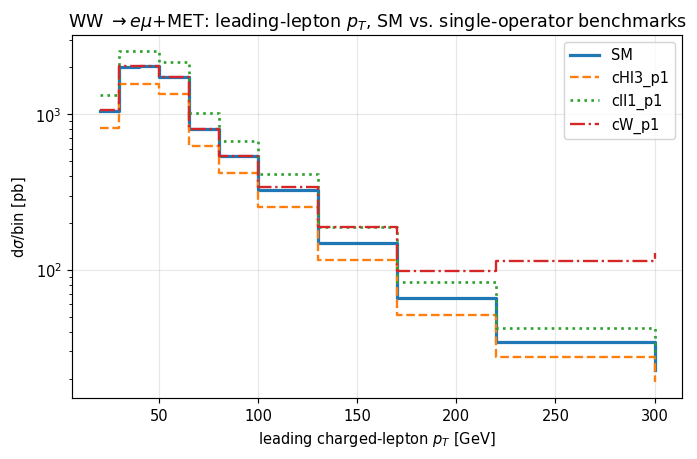

In [128]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
edges = ww["bins"]
for name, ls, lw in [("SM", "-", 2.2), ("cHl3_p1", "--", 1.6), ("cll1_p1", ":", 1.8), ("cW_p1", "-.", 1.6)]:
    ax.step(edges[:-1], ww["sumw"][name], where="post", label=name, ls=ls, lw=lw)
ax.set_xlabel("leading charged-lepton $p_T$ [GeV]")
ax.set_ylabel(r"d$\sigma$/bin [pb]")
ax.set_yscale("log")
ax.set_title(r"WW $\to e\mu$+MET: leading-lepton $p_T$, SM vs. single-operator benchmarks")
ax.legend()
plt.show()

Note the shape: the SMEFT benchmarks track the SM closely at low $p_T$ and
peel away in the tail — exactly the energy-growth behaviour dimension-6
operators are expected to produce, and the reason a *shape* fit (many bins)
is so much more powerful here than a single inclusive rate.

## Step 2 — Include all relevant operators, via reweighting

Rather than re-running MadGraph once per Wilson-coefficient point (slow),
`create_ww.sh` generates **one** SM-like sample and MadGraph's `reweight`
module computes, **per event**, the exact matrix-element weight at 34 other
benchmark points in the 6D Wilson-coefficient space
(`reweight_points.py`). Summing those weights per bin gives the exact
cross section at each benchmark point, for free (no new integration).

The response of any bin to the Wilson coefficients is an exact **quadratic
polynomial** (SM + linear interference + quadratic EFT$^2$ term):

$$
\sigma_{\rm bin}(c) = \theta_0 + \sum_i \theta_i\,c_i + \sum_{i\le j} \theta_{ij}\,c_i c_j .
$$

With 6 operators that's $1 + 6 + 6 + 15 = 28$ unknowns per bin — and
`reweight_points.fit_points()` supplies **exactly 28 points** (SM; $c_i=\pm1$
one at a time; $c_i=c_j=+1$ for every pair), so solving for $\theta$ is an
*exact* linear solve, not a least-squares fit. 6 further random points
(`validation_points()`) are held out to check the fitted surface predicts
MG5's own reweighted yields correctly.

In [129]:
labels = fl.term_labels()
print(f"{len(labels)} design-matrix terms for {len(OPS)} operators "
      f"(1 SM + {len(OPS)} linear + {len(OPS)} quadratic + {len(labels) - 1 - 2*len(OPS)} cross terms):")
print(labels)

28 design-matrix terms for 6 operators (1 SM + 6 linear + 6 quadratic + 15 cross terms):
['1', 'cW', 'cHWB', 'cHW', 'cHj3', 'cHl3', 'cll1', 'cW^2', 'cHWB^2', 'cHW^2', 'cHj3^2', 'cHl3^2', 'cll1^2', 'cW*cHWB', 'cW*cHW', 'cW*cHj3', 'cW*cHl3', 'cW*cll1', 'cHWB*cHW', 'cHWB*cHj3', 'cHWB*cHl3', 'cHWB*cll1', 'cHW*cHj3', 'cHW*cHl3', 'cHW*cll1', 'cHj3*cHl3', 'cHj3*cll1', 'cHl3*cll1']


In [130]:
val_df = pd.DataFrame(ww["validation"])[["name", "pred_total", "actual_total", "max_abs_rel_diff"]]
val_df["max_abs_rel_diff"] = val_df["max_abs_rel_diff"] * 100
val_df = val_df.rename(columns={"max_abs_rel_diff": "max |pred-actual|/actual per bin [%]"})
display(val_df.style.format({"pred_total": "{:.4g}", "actual_total": "{:.4g}",
                              "max |pred-actual|/actual per bin [%]": "{:.4f}"}))

,name,pred_total,actual_total,max |pred-actual|/actual per bin [%]
0,val0,7185,7185,0.0000
1,val1,7122,7122,0.0000
2,val2,7897,7897,0.0000
3,val3,9323,9323,0.0000
4,val4,9953,9953,0.0000
5,val5,7764,7764,0.0000


The fitted quadratic surface reproduces MadGraph's own reweighted yields at
held-out random points to well under 1% everywhere — the surface is a
trustworthy stand-in for "re-run MadGraph at any $c$" for the rest of this
notebook, at zero extra generation cost.

## Step 3 — Identify flat directions: build the likelihood with `iminuit`, assume SM ($c=0$)

We use the **Asimov** technique: "data" is defined to be *exactly* the SM
($c=0$) expectation, scaled to $\mathcal{L}=300\,\mathrm{fb}^{-1}$, with
Poisson variance $\sigma^2_{\rm bin}=\max(N_{\rm bin}^{\rm SM}, 1)$. Then

$$
\chi^2(c) = \sum_{\rm bins} \frac{\big(\mu_{\rm bin}(c) - \mu_{\rm bin}^{\rm SM}\big)^2}{\sigma^2_{\rm bin}}
$$

is guaranteed to have its global minimum exactly at $c=0$ with
$\chi^2=0$ — what MIGRAD/HESSE/MINOS actually tell us is *how tightly
curved* that minimum is in each direction. A direction that's easy for
MIGRAD to wander along without $\chi^2$ increasing is precisely a **flat
direction**.

This $\chi^2(c)$ is built directly from the *same* quadratic surface fitted
in step 2 (`fitlib.chi2_factory`) — it is quartic in $c$ overall (quadratic
model, squared), so it is sensitive to genuine flat *valleys*, not just to
the local linear (tangent-plane) approximation.

We also build the standard **linearized Fisher information matrix**,

$$
F_{ij} = \sum_{\rm bins}\frac{1}{\sigma_{\rm bin}^2}\frac{\partial \mu_{\rm bin}}{\partial c_i}\frac{\partial \mu_{\rm bin}}{\partial c_j}\bigg|_{c=0},
$$

for the PCA in step 4 — a pure linear-algebra object, always well-defined
even where a nonlinear fit might struggle numerically (as we'll see happens
for real in step 8).

In [131]:
F_ww = fl.linear_fisher_matrix(ww["theta"], ww["sigma2"])
print("Fisher matrix F_ij (WW, 300 fb^-1):")
display(fl.as_frame(F_ww).style.format("{:.3e}"))

Fisher matrix F_ij (WW, 300 fb^-1):


,cW,cHWB,cHW,cHj3,cHl3,cll1
cW,2.208e+06,6.442e+04,7.864e+04,-6.825e+06,3.567e+06,-3.721e+06
cHWB,6.442e+04,4.983e+03,-3.387e+03,-2.747e+05,1.024e+05,-1.087e+05
cHW,7.864e+04,-3.387e+03,1.197e+05,-2.875e+06,3.079e+06,-3.033e+06
cHj3,-6.825e+06,-2.747e+05,-2.875e+06,1.791e+08,-1.615e+08,1.607e+08
cHl3,3.567e+06,1.024e+05,3.079e+06,-1.615e+08,1.532e+08,-1.521e+08
cll1,-3.721e+06,-1.087e+05,-3.033e+06,1.607e+08,-1.521e+08,1.510e+08


In [132]:
m_ww_full = fl.fit_full(ww["theta"], ww["mu0"], ww["sigma2"])
m_ww_full

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 953              │
│ EDM = 1.87e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ cW   │  0.0000   │  0.0019   │  -0.0020   │   0.0020   │   -5    │    5    │       │
│ 1 │ cHWB │   0.000   │   0.024   │   -0.024   │   0.024    │   -5    │    5    │       │
│ 2 │ cHW  │   0.000   │   0.009   │   -0.009   │   0.010    │   -5    │    5    │       │
│ 3 │ cHj3 │     0     │  0.9e-3   │  -0.9e-3   │   0.9e-3   │   -5    │    5    │       │
│ 4 │ cHl3 │   0.000   │   0.015   │   -0.016   │   0.015    │   -5    │    5    │       │
│ 5 │ cll1 │   0.000   │   0.015   │   -0.016   │   0.015    │   -5    │    5    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          cW           │         cHWB          │          cHW          │         cHj3          │         cHl3          │         cll1          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │  -0.024   │   0.024   │  -0.009   │   0.010   │  -0.9e-3  │  0.9e-3   │  -0.016   │   0.015   │  -0.016   │   0.015   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬───────────────────────────────────────────────────────┐
│      │       cW     cHWB      cHW     cHj3     cHl3     cll1 │
├──────┼───────────────────────────────────────────────────────┤
│   cW │ 3.68e-06    -2e-6   -15e-6   0.9e-6    22e-6    21e-6 │
│ cHWB │    -2e-6 0.000578 -0.01e-3  11.5e-6 -0.01e-3 -0.02e-3 │
│  cHW │   -15e-6 -0.01e-3 8.68e-05  -4.5e-6 -0.11e-3 -0.10e-3 │
│ cHj3 │   0.9e-6  11.5e-6  -4.5e-6 7.52e-07   2.4e-6   1.6e-6 │
│ cHl3 │    22e-6 -0.01e-3 -0.11e-3   2.4e-6 0.000219  0.22e-3 │
│ cll1 │    21e-6 -0.02e-3 -0.10e-3   1.6e-6  0.22e-3 0.000215 │
└──────┴───────────────────────────────────────────────────────┘

In [133]:
cov_ww_minuit = np.array(m_ww_full.covariance)
corr_ww_minuit = fl.correlation_matrix(cov_ww_minuit)
print("Correlation matrix from the full 6-parameter Minuit fit:")
display(fl.as_frame(corr_ww_minuit).style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.3f}"))

Correlation matrix from the full 6-parameter Minuit fit:


,cW,cHWB,cHW,cHj3,cHl3,cll1
cW,1.000,-0.036,-0.835,0.538,0.789,0.761
cHWB,-0.036,1.000,-0.054,0.554,-0.016,-0.050
cHW,-0.835,-0.054,1.000,-0.552,-0.768,-0.737
cHj3,0.538,0.554,-0.552,1.000,0.189,0.124
cHl3,0.789,-0.016,-0.768,0.189,1.000,0.998
cll1,0.761,-0.050,-0.737,0.124,0.998,1.000


Watch the $c_{Hl3}$–$c_{ll1}$ entry above: it's the largest off-diagonal
correlation in the matrix, and visually close to $\pm 1$. That's the flat
direction step 6 explains. Let's quantify it precisely by inverting the
Fisher matrix directly (equivalent to the Minuit HESSE covariance at
$c=0$, since the Asimov cross term $(\mu(0)-\mu_0)\cdot\partial^2\mu$
vanishes exactly there — cross-checked numerically right below; we'll
repeat this same Fisher-vs-Minuit cross-check for the combined WW+ZZ fit
in step 9):

In [102]:
cov_ww_fisher = np.linalg.inv(F_ww)
i_hl3, i_ll1 = OPS.index("cHl3"), OPS.index("cll1")
sig_cHl3_ww = np.sqrt(cov_ww_fisher[i_hl3, i_hl3])
sig_cll1_ww = np.sqrt(cov_ww_fisher[i_ll1, i_ll1])
corr_ww_cHl3_cll1 = cov_ww_fisher[i_hl3, i_ll1] / (sig_cHl3_ww * sig_cll1_ww)

print(f"marginal sigma(cHl3) = {sig_cHl3_ww:.5f}")
print(f"marginal sigma(cll1) = {sig_cll1_ww:.5f}")
print(f"marginal corr(cHl3, cll1) = {corr_ww_cHl3_cll1:.6f}")
print()
print("max|cov_fisher - cov_minuit| =", np.max(np.abs(cov_ww_fisher - cov_ww_minuit)))

marginal sigma(cHl3) = 0.01577
marginal sigma(cll1) = 0.01561
marginal corr(cHl3, cll1) = 0.998095

max|cov_fisher - cov_minuit| = 2.9810496648623066e-05


$\mathrm{corr}(c_{Hl3}, c_{ll1}) \approx 0.998$: from WW alone, these two
operators are *almost* completely degenerate — you can trade one for the
other along a nearly-exact line and the predicted spectrum barely changes.
That's a flat direction. (Not the only strong correlation in the matrix —
e.g. $c_W$–$c_{HW}$ is sizeable too — but $c_{Hl3}$–$c_{ll1}$ is the
standout, and the one with the cleanest story, so it's our case study for
the rest of the notebook.)

**Why does inverting $F$ *exactly* reproduce Minuit's HESSE covariance?**
Because $F$ literally *is* half the Hessian of the `chi2()` function Minuit
differentiates — not "approximately, for small $c$", but exactly, at
$c=0$, thanks to the Asimov construction. Differentiate
$\chi^2(c)=\sum_{\rm bins}(\mu_{\rm bin}(c)-\mu_{\rm bin}^0)^2/\sigma_{\rm bin}^2$
twice:

$$
\frac{\partial^2\chi^2}{\partial c_j\partial c_k}\bigg|_{c=0}
= \sum_{\rm bins}\frac{2}{\sigma_{\rm bin}^2}
  \frac{\partial\mu_{\rm bin}}{\partial c_j}\frac{\partial\mu_{\rm bin}}{\partial c_k}
+ \underbrace{\sum_{\rm bins}\frac{2\big(\mu_{\rm bin}(0)-\mu_{\rm bin}^0\big)}{\sigma_{\rm bin}^2}
  \frac{\partial^2\mu_{\rm bin}}{\partial c_j\partial c_k}}_{\textstyle =\,0\ \text{(Asimov: }\mu(0)\equiv\mu^0\text{ exactly)}}
\;=\; 2F_{jk}.
$$

The second term would generally survive away from $c=0$ (the response
surface is quadratic in $c$, so $\chi^2(c)$ is quartic overall and its true
Hessian does vary with $c$) — but *at* $c=0$ specifically, Asimov data
makes that term vanish identically, leaving exactly $H_{jk}(0)=2F_{jk}$, no
approximation involved. Specialize to a single operator (the easiest way
to check this by hand) and it collapses to a scalar:

$$
H(0) = \frac{d^2\chi^2}{dc^2}\bigg|_{c=0}
     = \sum_{i\,\in\,{\rm bins}} 2\left(\frac{\mathrm{Lin}^i}{\sigma^i_{\rm SM}}\right)^{\!2}
     = 2F_{11},
\qquad \mathrm{Lin}^i \equiv \frac{\partial\mu_i}{\partial c}\bigg|_{c=0},
$$

i.e. exactly `2 * fl.linear_fisher_matrix(...)[i, i]`. Let's check that
numerically instead of just trusting the algebra, by finite-differencing
the *actual* `chi2()` object along the $c_{Hl3}$ and $c_{ll1}$ axes:

In [103]:
chi2_ww = fl.chi2_factory(ww["theta"], ww["mu0"], ww["sigma2"])


def finite_diff_hessian_diag(chi2_fn, i, n_ops, h):
    # Textbook central 2nd-derivative stencil: (f(h) - 2f(0) + f(-h)) / h^2.
    # f(0) = chi2(c=0) = 0 exactly here (Asimov), but the -2*f(0) term is
    # kept explicit so this is recognizable as the standard formula, not a
    # shortcut that only works for this particular chi2.
    c0 = np.zeros(n_ops)
    cp, cm = c0.copy(), c0.copy()
    cp[i], cm[i] = h, -h
    return (chi2_fn(cp) - 2 * chi2_fn(c0) + chi2_fn(cm)) / h ** 2


for op, i in [("cHl3", i_hl3), ("cll1", i_ll1)]:
    # step size: small compared to THIS operator's own single-parameter
    # (diagonal-only, no marginalization) Fisher width -- not the marginal
    # sigma printed above, which is much wider thanks to the correlation.
    h = 0.05 / np.sqrt(F_ww[OPS.index(op), OPS.index(op)])
    H_ii = finite_diff_hessian_diag(chi2_ww, i, len(OPS), h)
    print(f"{op:5s}: finite-diff d^2(chi2)/dc^2|_0 = {H_ii:12.4f}   "
          f"2 * F_ww[{op},{op}] = {2 * F_ww[i, i]:12.4f}   (step h = {h:.2e})")

cHl3 : finite-diff d^2(chi2)/dc^2|_0 = 306429412.9095   2 * F_ww[cHl3,cHl3] = 306429412.8980   (step h = 4.04e-06)
cll1 : finite-diff d^2(chi2)/dc^2|_0 = 301946171.0975   2 * F_ww[cll1,cll1] = 301946171.0996   (step h = 4.07e-06)


Matches to numerical precision, for both operators — the Hessian-of-$\chi^2$
identity above isn't just a plausibility argument, it's exactly what's
happening under the hood every time `m.hesse()` and `np.linalg.inv(F)`
agree. This is also the precise, general statement of what the lecture
slide's $V^{-1}$ *is*: not "the variance" by definition, but **(twice) the
Hessian of a channel's own $\chi^2$ contribution with respect to its own
rate parameter** — which, for the Gaussian/Asimov-Poisson $\chi^2$ used in
this whole notebook, happens to evaluate to exactly $1/\sigma_{\rm bin}^2$.
Same numeric answer, more general and more precise justification — see the
cross-reference note after step 5 for how this plugs into $F=\mathcal{A}^TV^{-1}\mathcal{A}$.

## Step 4 — Use PCA to reduce the dimensionality

Diagonalizing $F$ gives an orthogonal basis of "principal" directions in
Wilson-coefficient space, each with its own curvature (eigenvalue) —
exactly a PCA of the Fisher information. Large eigenvalue = tightly
constrained direction; small eigenvalue = flat direction.

In [104]:
w_ww, v_ww = fl.eigh_sorted(F_ww)
print("Eigenvalues (descending):")
for k, wk in enumerate(w_ww):
    print(f"  lambda_{k+1} = {wk:12.4f}" + (f"   (ratio to next: {w_ww[k]/w_ww[k+1]:.2f}x)" if k+1 < len(w_ww) else ""))

Eigenvalues (descending):
  lambda_1 = 478074264.7814   (ratio to next: 72.40x)
  lambda_2 = 6602914.4257   (ratio to next: 7.22x)
  lambda_3 =  914182.7406   (ratio to next: 30.89x)
  lambda_4 =   29591.1565   (ratio to next: 16.26x)
  lambda_5 =    1819.4764   (ratio to next: 1.06x)
  lambda_6 =    1713.0380


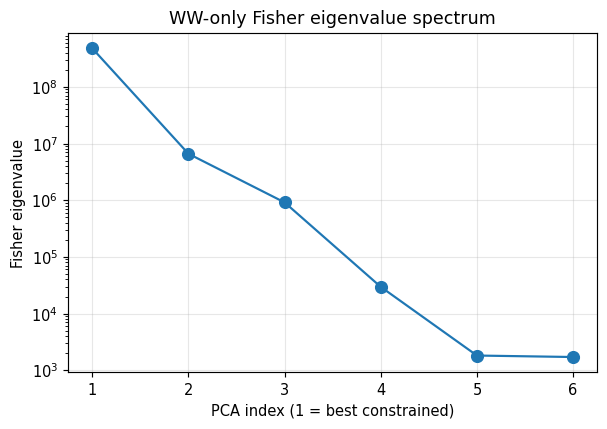

In [105]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(range(1, len(w_ww) + 1), w_ww, "o-", ms=8)
ax.set_xticks(range(1, len(w_ww) + 1))
ax.set_xlabel("PCA index (1 = best constrained)")
ax.set_ylabel("Fisher eigenvalue")
ax.set_title("WW-only Fisher eigenvalue spectrum")
plt.show()

In [106]:
eigvec_df = fl.as_frame(v_ww, columns=[f"PC{k+1}" for k in range(len(OPS))])
display(eigvec_df.style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}"))

,PC1,PC2,PC3,PC4,PC5,PC6
cW,-0.017,0.453,0.882,-0.106,-0.064,-0.029
cHWB,-0.001,0.021,-0.005,0.034,-0.393,0.918
cHW,-0.011,-0.046,0.162,0.924,0.325,0.107
cHj3,0.606,-0.703,0.361,-0.087,-0.016,0.015
cHl3,-0.564,-0.414,0.171,0.189,-0.615,-0.260
cll1,0.560,0.357,-0.189,0.300,-0.597,-0.276


There's a clean ~16x gap between PC4 and PC5, and then PC5/PC6 are nearly
degenerate (~1.06x apart) — textbook justification for keeping the first
**$k=4$** principal components and treating the last 2 as "too flat to
trust in a simultaneous 6-parameter fit". Look at PC6 (the flattest
direction) in the table above: it should be dominated by $c_{Hl3}$ and
$c_{ll1}$ with opposite-ish weight and everything else small — exactly the
flat direction step 3 flagged.

In [107]:
K_KEEP = 4
print(f"Keeping k = {K_KEEP} principal components "
      f"(dropping eigenvalues {w_ww[K_KEEP:].round(1)}, "
      f"the near-degenerate flat pair dominated by cHl3/cll1).")

Keeping k = 4 principal components (dropping eigenvalues [1819.5 1713. ], the near-degenerate flat pair dominated by cHl3/cll1).


## Step 5 — Prove you can now fit the reduced parameter space simultaneously

`fit_reduced()` reparametrizes $c = V_k d$ where $V_k$ is the first
$k=4$ eigenvectors, leaves $d_1,\dots,d_4$ free, and implicitly fixes the
2 flattest directions to exactly 0 (they're never populated by $V_k d$).
It calls the exact same `chi2()` surface as the full fit — this is a
statement about the same physical model in a better-conditioned
parametrization, not a different, easier one.

In [108]:
m_ww_red = fl.fit_reduced(ww["theta"], ww["mu0"], ww["sigma2"], v_ww, K_KEEP)
m_ww_red

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 293              │
│ EDM = 6.62e-22 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ d1   │     0     │  0.05e-3  │  -0.05e-3  │  0.05e-3   │   -20   │   20    │       │
│ 1 │ d2   │     0     │  0.4e-3   │  -0.4e-3   │   0.4e-3   │   -20   │   20    │       │
│ 2 │ d3   │  0.0000   │  0.0010   │  -0.0010   │   0.0011   │   -20   │   20    │       │
│ 3 │ d4   │   0.000   │   0.006   │   -0.006   │   0.006    │   -20   │   20    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          d1           │          d2           │          d3           │          d4           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.05e-3  │  0.05e-3  │  -0.4e-3  │  0.4e-3   │  -0.0010  │  0.0011   │  -0.006   │   0.006   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │       d1       d2       d3       d4 │
├────┼─────────────────────────────────────┤
│ d1 │ 2.09e-09        0       -0       -0 │
│ d2 │        0 1.51e-07        0        0 │
│ d3 │       -0        0 1.09e-06       -0 │
│ d4 │       -0        0       -0 3.38e-05 │
└────┴─────────────────────────────────────┘

Converges cleanly (valid minimum, valid HESSE, valid MINOS on every
parameter) — contrast this with what happens if we try the full 6D fit on
a sample that's much less sensitive to $c_W$ (step 8). We can map the
reduced-fit covariance back onto the *physical* Wilson coefficients via
$\mathrm{Cov}(c) = V_k\,\mathrm{Cov}(d)\,V_k^T$ (a rank-4 matrix in a 6D
space, by construction — the 2 dropped directions get exactly 0 variance
here, which is the honest statement "we did not attempt to constrain them
in this fit", not "they are known to be 0"):

In [109]:
Vk_ww = v_ww[:, :K_KEEP]
cov_d_ww = np.array(m_ww_red.covariance)
cov_c_from_reduced = Vk_ww @ cov_d_ww @ Vk_ww.T
print("Covariance on the physical (cW,...,cll1), reconstructed from the k=4 reduced fit:")
display(fl.as_frame(cov_c_from_reduced).style.format("{:.2e}"))

Covariance on the physical (cW,...,cll1), reconstructed from the k=4 reduced fit:


,cW,cHWB,cHW,cHj3,cHl3,cll1
cW,1.26e-06,-1.25e-07,-3.16e-06,6.13e-07,-5.42e-07,-1.23e-06
cHWB,-1.25e-07,3.87e-08,1.05e-06,-1.04e-07,2.14e-07,3.45e-07
cHW,-3.16e-06,1.05e-06,2.89e-05,-2.66e-06,5.95e-06,9.33e-06
cHj3,6.13e-07,-1.04e-07,-2.66e-06,4.76e-07,-4.48e-07,-9.96e-07
cHl3,-5.42e-07,2.14e-07,5.95e-06,-4.48e-07,1.27e-06,1.86e-06
cll1,-1.23e-06,3.45e-07,9.33e-06,-9.96e-07,1.86e-06,3.10e-06


**Cross-reference: steps 3–5 above are exactly the "Hands-on session" PCA
slide from the lecture**, symbol for symbol. If you want to read the code
with the slide open next to it:

- **$V^{-1}=\mathrm{diag}(V_1^{-1},\dots,V_m^{-1})$** (block-diagonal
  inverse covariance, one block per channel $\alpha$). Precisely,
  $V_\alpha^{-1}$ is (twice) the Hessian of channel $\alpha$'s own
  $\chi^2$ contribution with respect to its own rate parameter — see the
  derivation and numeric check right after step 3 — *not* "the variance"
  by definition, just numerically equal to it here because that's what the
  Hessian of a Gaussian/Asimov-Poisson $\chi^2$ works out to. In code
  that's `sigma2` (`ww["sigma2"]`, the Asimov Poisson variance per bin)
  wherever you see `/ sigma2` in `fitlib.py`. Every **bin** is its own
  trivial $1\times1$ block here — no bin-bin covariance is modeled — so
  $V^{-1}$ collapses to plain `1/sigma2`. The genuinely multi-channel case
  ($m=2$ blocks) shows up for real in step 9, where `sigma2_comb` is WW's
  own block and ZZ's own block concatenated end to end, exactly
  $\mathrm{diag}(V_1^{-1}, V_2^{-1})$.
- **$\mathcal{A}$**, with $A^\alpha_j$ = the linear contribution of
  operator $j$ to channel $\alpha$, is the linear-in-$c$ slice of the
  fitted response surface, `theta[1:1+n_ops, :]` — pulled out inside
  `linear_fisher_matrix()` under the literal local name `A`:
  $A^\alpha_j \equiv \partial\mu_\alpha/\partial c_j$ at $c=0$.
- **$F=\mathcal{A}^TV^{-1}\mathcal{A}$** is exactly
  `fl.linear_fisher_matrix()`'s `return (A / sigma2) @ A.T`, called in
  step 3 as `F_ww = fl.linear_fisher_matrix(ww["theta"], ww["sigma2"])`.
  Step 3's own formula, $F_{ij}=\sum_{\rm bins}\sigma_{\rm bin}^{-2}\,
  \partial_i\mu\,\partial_j\mu$, is this same equation written in index
  form instead of matrix form.
- **$F=\mathcal{R}^T\Lambda\mathcal{R}$** is step 4's
  `w_ww, v_ww = fl.eigh_sorted(F_ww)` (a descending-sorted wrapper around
  `np.linalg.eigh`). `w_ww` is $\Lambda$'s diagonal; `v_ww` stores
  eigenvectors as **columns** (`v_ww[:, k]` = $k$-th eigenvector, numpy's
  own convention), so `v_ww` $\leftrightarrow\mathcal{R}^T$ — i.e.
  $\mathcal{R}$ itself, "rows are eigenvectors" exactly as the slide
  captions it, is `v_ww.T`. The `eigvec_df` table above is $\mathcal{R}^T$
  printed with its columns labeled PC1...PC6.
- **$p_i=\mathcal{R}_i^kc_k=\sum_kx_i^kc_k$** — rotating physical Wilson
  coefficients into PCA coordinates — is step 5's reparametrization run
  **backwards**: `c = Vk @ d` (`Vk = v_ww[:, :K_KEEP]`) is
  $c=\mathcal{R}^Td$, the inverse of $p=\mathcal{R}c$ (valid because
  $\mathcal{R}$ is orthogonal, $\mathcal{R}^{-1}=\mathcal{R}^T$) — exactly
  how the reduced fit turns PCA coordinates $d$ back into physical
  couplings. The forward direction — projecting a physical $c$ onto the
  PCA axes, literally $p=\mathcal{R}c$ — is `v_ww.T @ c`: a dot product
  against `eigvec_df`'s own columns. And `cov_c_from_reduced = Vk_ww @
  cov_d_ww @ Vk_ww.T`, at the very end of step 5, is that same rotation
  law applied to a covariance matrix instead of a single vector.

One more payoff this buys you for free: since $\mathrm{Cov}(c) = F^{-1} =
\mathcal{R}^T\Lambda^{-1}\mathcal{R}$, the variance along principal
direction $i$ is exactly $1/\lambda_i$ — "small eigenvalue" and "flat
direction" aren't just analogous, they're the same statement.

## Step 6 — The $c_{Hl3}$–$c_{ll1}$ degeneracy: why does it happen?

Section 0 already showed the mechanism directly in the UFO source:

$$\delta G_F = \frac{(2\,c_{Hl3} - c_{ll1})\,\hat v^2}{\Lambda^2}$$

is a **universal** shift that enters essentially every electroweak
coupling in the model (because the input-scheme parameters $\hat v$, `ee`,
`sth`, `cth`, ... are all redefined in terms of the measured EW inputs, and
$c_{Hl3}$/$c_{ll1}$ shift that relationship). Any EW process picks up
*some* sensitivity to the $(2 c_{Hl3} - c_{ll1})$ combination just from
this, independent of its own diagrams — a shared "knob" that pulls
$c_{Hl3}$ and $c_{ll1}$ toward moving together.

Let's look at the fitted valley directly, using `fitlib.chi2_scan_2d` to
evaluate the *true* (not linearized) $\chi^2$ on a grid in the
$(c_{Hl3}, c_{ll1})$ plane, holding the other 4 operators fixed at 0.

In [110]:
F2_ww = F_ww[np.ix_([i_hl3, i_ll1], [i_hl3, i_ll1])]
w2_ww, v2_ww = fl.eigh_sorted(F2_ww)
flat_dir_ww = v2_ww[:, -1]
slope_ww = flat_dir_ww[1] / flat_dir_ww[0]
print(f"2x2 (cHl3, cll1) conditional sub-block eigenvalues: {w2_ww}")
print(f"curvature contrast (tight axis / flat axis): {w2_ww[0] / w2_ww[1]:.1f}x")
print(f"flat direction (unit vector): {flat_dir_ww}")
print(f"flat-direction slope d(cll1)/d(cHl3) = {slope_ww:.4f}")

2x2 (cHl3, cll1) conditional sub-block eigenvalues: [3.04172911e+08 1.48813791e+04]
curvature contrast (tight axis / flat axis): 20439.8x
flat direction (unit vector): [-0.7044963  -0.70970766]
flat-direction slope d(cll1)/d(cHl3) = 1.0074


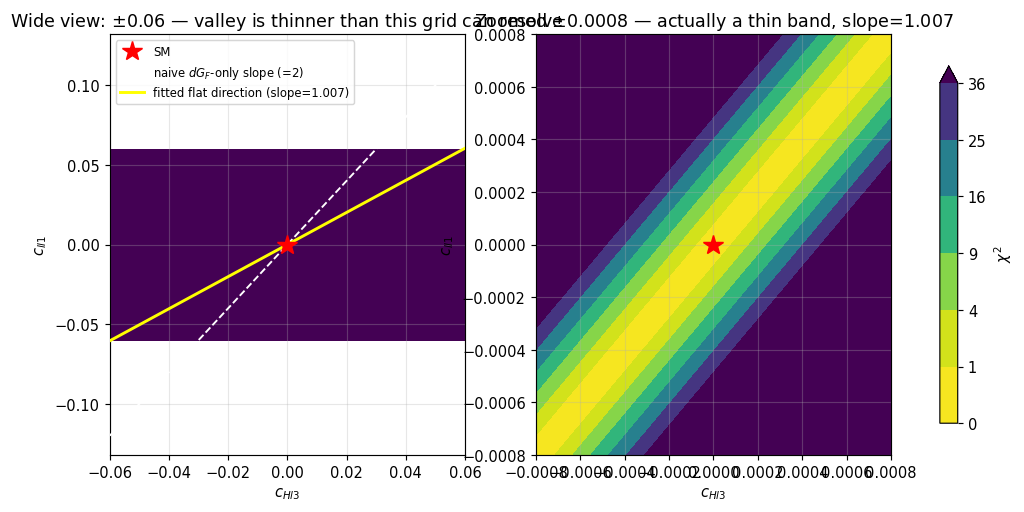

In [111]:
grid_wide = np.linspace(-0.06, 0.06, 81)
grid_zoom = np.linspace(-0.0008, 0.0008, 121)
Xw, Yw, Zw = fl.chi2_scan_2d(ww["theta"], ww["mu0"], ww["sigma2"], "cHl3", "cll1", grid_wide)
Xz, Yz, Zz = fl.chi2_scan_2d(ww["theta"], ww["mu0"], ww["sigma2"], "cHl3", "cll1", grid_zoom)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
levels = [0, 1, 4, 9, 16, 25, 36]

# NOTE on the wide panel: the true valley here is only ~2e-4 wide (see the
# zoomed panel), while this grid's spacing is ~1.5e-3 -- an order of
# magnitude too coarse to resolve it. contourf is therefore *correctly*
# showing "excluded everywhere" (a genuinely honest picture of what a
# grid this coarse can tell you), but the valley itself would otherwise be
# invisible -- so we draw it explicitly as a solid line using the fitted
# direction from the 2x2 eigendecomposition above, not by resolving it on
# the grid.
cs = axes[0].contourf(Xw, Yw, Zw, levels=levels, cmap="viridis_r", extend="max")
axes[0].plot(0, 0, "r*", ms=14, zorder=5, label="SM")
xs = np.linspace(-0.06, 0.06, 5)
axes[0].plot(xs, 2 * xs, "w--", lw=1.3, zorder=4, label="naive $dG_F$-only slope (=2)")
axes[0].plot(xs, slope_ww * xs, color="yellow", lw=2.0, zorder=4,
             label=f"fitted flat direction (slope={slope_ww:.3f})")
axes[0].set_title("Wide view: $\\pm 0.06$ — valley is thinner than this grid can resolve")
axes[0].set_xlabel("$c_{Hl3}$"); axes[0].set_ylabel("$c_{ll1}$")
axes[0].legend(loc="upper left", fontsize=8)

cs2 = axes[1].contourf(Xz, Yz, Zz, levels=levels, cmap="viridis_r", extend="max")
axes[1].plot(0, 0, "r*", ms=14)
axes[1].set_title(f"Zoomed $\\pm 0.0008$ — actually a thin band, slope={slope_ww:.3f}")
axes[1].set_xlabel("$c_{Hl3}$"); axes[1].set_ylabel("$c_{ll1}$")
fig.colorbar(cs2, ax=axes, shrink=0.85, label=r"$\chi^2$")
plt.show()

**Reading the two panels:** zoomed out (left), the valley itself (yellow
solid line — the fitted direction from the $2\times2$ eigendecomposition
above) is *thinner than this grid can resolve* — every grid point off that
exact line already sits at $\chi^2>36$, which is precisely what
$\mathrm{corr}(c_{Hl3},c_{ll1})\approx 0.998$ (indistinguishable from 1 by
eye) means in practice. Zoomed in by ~100x (right), it's actually a thin
but *finite-width* band: WW alone constrains the perpendicular direction
very tightly, just not the direction along the band.

**An honest caveat on the slope.** The naive "$\delta G_F$ alone" argument
predicts the flat direction should sit exactly along $c_{ll1}=2\,c_{Hl3}$
(dashed white line, left panel) — but the *fitted* valley (solid yellow
line; printed above) has slope $\approx 1.01$, much closer to $c_{ll1}\approx c_{Hl3}$
than to the naive $2{:}1$ prediction. Section 0 tells
us why this isn't a contradiction: $\delta G_F$ is the *universal* piece,
but WW's own charged-current vertex carries an *additional*, direct
$c_{ll1}$-only term ($GC_{507}$, no $c_{Hl3}$ counterpart) that pulls the
fitted valley away from the naive $\delta G_F$-only prediction. Pinning
down the exact fitted slope analytically means tracking that direct term
plus every other coupling in the full $2\to4$ amplitude and the binned
kinematic weighting — a fun exercise, but a rabbit hole beyond today. The
robust, load-bearing fact for what follows isn't the precise slope value;
it's that **the direction is process-dependent**, because different
processes carry different direct vertex terms on top of the shared
universal piece. Step 7 makes that concrete.

## Step 7 — Can you find a process that, combined with WW, closes this direction?

We need a *second* measurement whose fitted $(c_{Hl3}, c_{ll1})$ valley
points a **different** way — then the two valleys cross at a point instead
of overlapping along the same line.

### First guess: charged-current Drell-Yan, $pp\to e\nu$

The obvious "add one more process" choice: `create_ccdy.sh` generates
$pp\to e^+\nu_e$ (+ c.c.), `NP=1` — genuinely different production (a light
quark current via $c_{Hj3}$ instead of $q\bar q'\to WW$), same leptonic $W$
decay vertex as WW. Let's check its $(c_{Hl3}, c_{ll1})$ direction.

In [112]:
CCDY_BINS = np.array([10, 14, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 48, 55, 70, 100, 190])

print("Loading CC-DY sample...")
ccdy = fl.load_sample(CCDY_LHE, CCDY_BINS, lumi_fb=LUMI_FB)
F_ccdy = fl.linear_fisher_matrix(ccdy["theta"], ccdy["sigma2"])

print()
print("Fisher diagonal (cW, cHWB, cHW should be ~0 -- no WWZ/WWgamma vertex in single-W production):")
print({op: round(float(v), 4) for op, v in zip(OPS, np.diag(F_ccdy))})

Loading CC-DY sample...
    unweighted_events.lhe.gz: 60000 events read, SM yield in range = 5.698e+08 pb
    surface validation: worst held-out point 'val4', max |Delta bin| / bin = 0.00%

Fisher diagonal (cW, cHWB, cHW should be ~0 -- no WWZ/WWgamma vertex in single-W production):
{'cW': 0.0, 'cHWB': 0.0, 'cHW': 0.0, 'cHj3': 2512863845638.788, 'cHl3': 2512863845638.787, 'cll1': 2512863845638.787}


In [113]:
F2_ccdy = F_ccdy[np.ix_([i_hl3, i_ll1], [i_hl3, i_ll1])]
w2_ccdy, v2_ccdy = fl.eigh_sorted(F2_ccdy)
flat_dir_ccdy = v2_ccdy[:, -1]
cos_ww_ccdy = abs(np.dot(flat_dir_ww, flat_dir_ccdy))

print(f"CC-DY flat direction: {flat_dir_ccdy}, slope = {flat_dir_ccdy[1]/flat_dir_ccdy[0]:.4f}")
print(f"WW flat direction:    {flat_dir_ww}, slope = {slope_ww:.4f}")
print(f"cosine(WW, CC-DY) = {cos_ww_ccdy:.6f}   (1 - cos = {1 - cos_ww_ccdy:.2e})")

CC-DY flat direction: [-0.70710678 -0.70710678], slope = 1.0000
WW flat direction:    [-0.7044963  -0.70970766], slope = 1.0074
cosine(WW, CC-DY) = 0.999993   (1 - cos = 6.79e-06)


**Essentially the same direction** — cosine overlap $>0.99999$. Combining
WW with CC-DY would **not** meaningfully close the flat direction: two
nearly-identical lines still cross at a very shallow angle, so the
combined uncertainty barely shrinks along the flat direction (feel free to
verify with `F_ww + F_ccdy` — same method as step 9's `F_ww + F_zz`).

**Why doesn't it work?** Both WW and CC-DY are **charged-current**
processes: every leptonic vertex in both is the *same* bare $e\,\nu\,W$
vertex we grepped in Section 0, carrying only the direct $c_{ll1}$ term (no
direct $c_{Hl3}$ term at all). Swapping the production side (quark current
vs. $WW$ pair-production) doesn't change *how the leptonic side weights
$c_{Hl3}$ vs. $c_{ll1}$* — so no new relative information.

### The real answer: a second *multiboson* process, but neutral-current

We need a process built from the **other** vertex Section 0 found: the bare
$Z\to e^+e^-$ vertex, which carries a *direct* term for *both* $c_{Hl3}$
and $c_{ll1}$ (coherently, along the same $(2,-1)$ ratio as $\delta G_F$ —
but as step 6 showed, "same universal ratio" does not mean "same fitted
valley", because WW's *own* direct term is different again). Concretely:

$$pp \to Z/\gamma^*\,Z/\gamma^* \to e^+e^-\mu^+\mu^-, \quad NP=1.$$

This also keeps the lecture's "multiboson" theme (rather than reaching for
plain Drell-Yan again), and it costs nothing on the $c_W/c_{HW}/c_{HWB}$
side: there's no neutral triple-gauge-coupling vertex ($ZZZ$/$ZZ\gamma$/
$Z\gamma\gamma$) at dimension six in SMEFT, so this sample brings no *new*
handle on those three — but it never needed to, since they were never part
of the degenerate direction to begin with. Opposite-flavour final state
($e^+e^-\mu^+\mu^-$, not $4e$/$4\mu$) again avoids identical-particle
combinatorics for free (and this final state is already its own charge
conjugate, unlike WW).

## Step 8 — Generate a prediction for the new process, and repeat steps 1–5

Same pipeline, same 6-operator basis, same benchmark grid, same
`fitlib` code path — genuinely apples-to-apples with WW, which is exactly
what makes step 9's matrix comparison meaningful instead of "two different
analyses that happen to both produce a 6x6 matrix".

In [114]:
ZZ_BINS = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 85, 105, 130, 160, 200, 260, 400])

print("Loading ZZ sample...")
zz = fl.load_sample(ZZ_LHE, ZZ_BINS, lumi_fb=LUMI_FB)

Loading ZZ sample...
    [warn] unweighted_events.lhe.gz: 8/8000 events fell outside [10.0, 400.0] GeV (widen `bins`?)
    unweighted_events.lhe.gz: 8000 events read, SM yield in range = 96.61 pb
    surface validation: worst held-out point 'val3', max |Delta bin| / bin = 0.00%


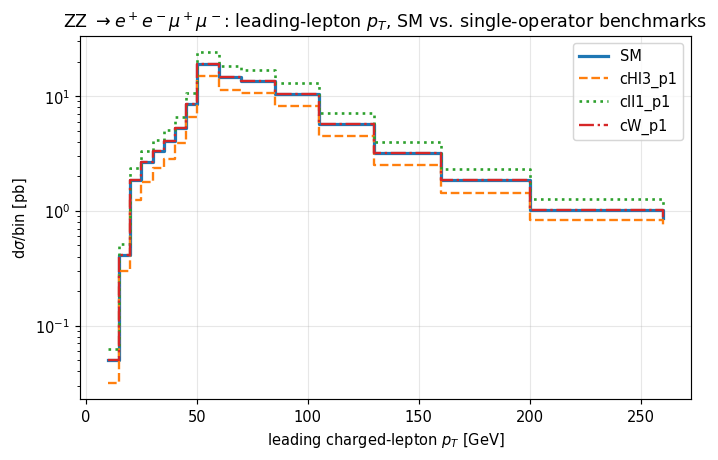

In [115]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
edges = zz["bins"]
for name, ls, lw in [("SM", "-", 2.2), ("cHl3_p1", "--", 1.6), ("cll1_p1", ":", 1.8), ("cW_p1", "-.", 1.6)]:
    ax.step(edges[:-1], zz["sumw"][name], where="post", label=name, ls=ls, lw=lw)
ax.set_xlabel("leading charged-lepton $p_T$ [GeV]")
ax.set_ylabel(r"d$\sigma$/bin [pb]")
ax.set_yscale("log")
ax.set_title(r"ZZ $\to e^+e^-\mu^+\mu^-$: leading-lepton $p_T$, SM vs. single-operator benchmarks")
ax.legend()
plt.show()

Note the much smaller cross section than WW (a low-rate, high-purity
channel — 4 leptons is a very clean but rare final state) — and notice the
`cW_p1` curve sits essentially on top of the SM curve: with no fermion-line
vertex depending on $c_W$ in this process, MadGraph's reweighting recomputes
the same amplitude, giving (numerically) the same weight. We'll see that as
an *exact* zero in the Fisher matrix next.

In [24]:
F_zz = fl.linear_fisher_matrix(zz["theta"], zz["sigma2"])
print("Fisher matrix F_ij (ZZ, 300 fb^-1):")
display(fl.as_frame(F_zz).style.format("{:.3e}"))
print()
print("cW row/column is exactly 0.0 -- not small-MC-noise-consistent-with-zero, but bit-for-bit exact:",
      "cW diag =", F_zz[OPS.index('cW'), OPS.index('cW')])

Fisher matrix F_ij (ZZ, 300 fb^-1):


,cW,cHWB,cHW,cHj3,cHl3,cll1
cW,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
cHWB,0.000e+00,6.391e+05,1.632e+03,2.222e+05,1.426e+05,1.511e+04
cHW,0.000e+00,1.632e+03,2.329e+03,-1.791e+04,2.017e+04,-1.989e+04
cHj3,0.000e+00,2.222e+05,-1.791e+04,1.867e+06,-1.784e+06,1.739e+06
cHl3,0.000e+00,1.426e+05,2.017e+04,-1.784e+06,1.911e+06,-1.774e+06
cll1,0.000e+00,1.511e+04,-1.989e+04,1.739e+06,-1.774e+06,1.682e+06



cW row/column is exactly 0.0 -- not small-MC-noise-consistent-with-zero, but bit-for-bit exact: cW diag = 0.0


In [25]:
w_zz, v_zz = fl.eigh_sorted(F_zz)
print("ZZ eigenvalues (descending):", w_zz)
print("(exactly one zero eigenvalue -- the cW direction, unconstrained by this process alone)")

ZZ eigenvalues (descending): [5.35392821e+06 7.43617354e+05 3.21296966e+03 3.87938755e+02
 1.27043912e+02 0.00000000e+00]
(exactly one zero eigenvalue -- the cW direction, unconstrained by this process alone)


Now try the full 6-parameter fit on ZZ **alone**, exactly like step 3:

In [26]:
m_zz_full = fl.fit_full(zz["theta"], zz["mu0"], zz["sigma2"])
m_zz_full

    [minos] raised RuntimeError: Function minimum is not valid: <FMin algorithm='Migrad' edm=3.775187048493238e-18 edm_goal=0.0002 errordef=1.0 fval=0.0 has_accurate_covar=False has_covariance=True has_made_posdef_covar=False has_parameters_at_limit=False has_posdef_covar=False has_reached_call_limit=False has_valid_parameters=False hesse_failed=True is_above_max_edm=False is_valid=False nfcn=299 ng2=0 ngrad=0 nhessian=0 reduced_chi2=nan time=-0.002879000036045909>
    (expected if a direction is exactly/near flat -- MINOS has to find where chi2 rises by 1, and can't if it never does within the scan range. Check m.merrors[...].is_valid and the HESSE covariance/correlation matrix instead.)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 299              │
│ EDM = 3.78e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ cW   │     0     │     0     │            │            │   -5    │    5    │       │
│ 1 │ cHWB │     0     │     0     │            │            │   -5    │    5    │       │
│ 2 │ cHW  │     0     │     0     │            │            │   -5    │    5    │       │
│ 3 │ cHj3 │     0     │     0     │            │            │   -5    │    5    │       │
│ 4 │ cHl3 │     0     │     0     │            │            │   -5    │    5    │       │
│ 5 │ cll1 │     0     │     0     │            │            │   -5    │    5    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

**This fails** — invalid minimum, HESSE failure, covariance not positive
definite. This is not a bug: with $c_W$ *exactly* unconstrained by this
process, the Fisher matrix is exactly singular, and there is no
well-defined "the uncertainty on $c_W$ from ZZ alone" to report. This is
precisely the failure mode step 4's PCA motivation warned about — and a
genuine, reproducible illustration of why you can't always just throw every
operator you can think of into a simultaneous fit.

The PCA-reduced fit, dropping exactly the 2 flattest directions (as in step
5), has no such problem:

In [27]:
m_zz_red = fl.fit_reduced(zz["theta"], zz["mu0"], zz["sigma2"], v_zz, K_KEEP)
m_zz_red

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 254              │
│ EDM = 6.58e-24 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ d1   │     0     │  0.4e-3   │  -0.4e-3   │   0.4e-3   │   -20   │   20    │       │
│ 1 │ d2   │  0.0000   │  0.0012   │  -0.0012   │   0.0012   │   -20   │   20    │       │
│ 2 │ d3   │   0.000   │   0.018   │   -0.018   │   0.018    │   -20   │   20    │       │
│ 3 │ d4   │   0.00    │   0.05    │   -0.05    │    0.05    │   -20   │   20    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          d1           │          d2           │          d3           │          d4           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.4e-3  │  0.4e-3   │  -0.0012  │  0.0012   │  -0.018   │   0.018   │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │       d1       d2       d3       d4 │
├────┼─────────────────────────────────────┤
│ d1 │ 1.87e-07        0        0        0 │
│ d2 │        0 1.34e-06        0        0 │
│ d3 │        0        0 0.000311       -0 │
│ d4 │        0        0       -0  0.00258 │
└────┴─────────────────────────────────────┘

Converges cleanly. Now the $(c_{Hl3}, c_{ll1})$ valley for ZZ, same
recipe as step 6 (note the different, much wider zoom scale on the right
panel — ZZ's much smaller cross section means much larger statistical
uncertainties overall):

In [28]:
F2_zz = F_zz[np.ix_([i_hl3, i_ll1], [i_hl3, i_ll1])]
w2_zz, v2_zz = fl.eigh_sorted(F2_zz)
flat_dir_zz = v2_zz[:, -1]
slope_zz = flat_dir_zz[1] / flat_dir_zz[0]
print(f"2x2 (cHl3, cll1) conditional sub-block eigenvalues: {w2_zz}")
print(f"flat direction: {flat_dir_zz}, slope = {slope_zz:.4f}")

cos_ww_zz = abs(np.dot(flat_dir_ww, flat_dir_zz))
print(f"\ncosine(WW direction, ZZ direction) = {cos_ww_zz:.6f}  (1 - cos = {1 - cos_ww_zz:.2e})")
print(f"cf. cosine(WW, CC-DY) = {cos_ww_ccdy:.6f}  (1 - cos = {1 - cos_ww_ccdy:.2e})")
print(f"-> ZZ's direction is ~{(1 - cos_ww_zz) / (1 - cos_ww_ccdy):.0f}x further from 'parallel to WW' than CC-DY's is.")

2x2 (cHl3, cll1) conditional sub-block eigenvalues: [3573532.49956524   19017.73834984]
flat direction: [-0.68391396 -0.72956268], slope = 1.0667

cosine(WW direction, ZZ direction) = 0.999591  (1 - cos = 4.09e-04)
cf. cosine(WW, CC-DY) = 0.999993  (1 - cos = 6.79e-06)
-> ZZ's direction is ~60x further from 'parallel to WW' than CC-DY's is.


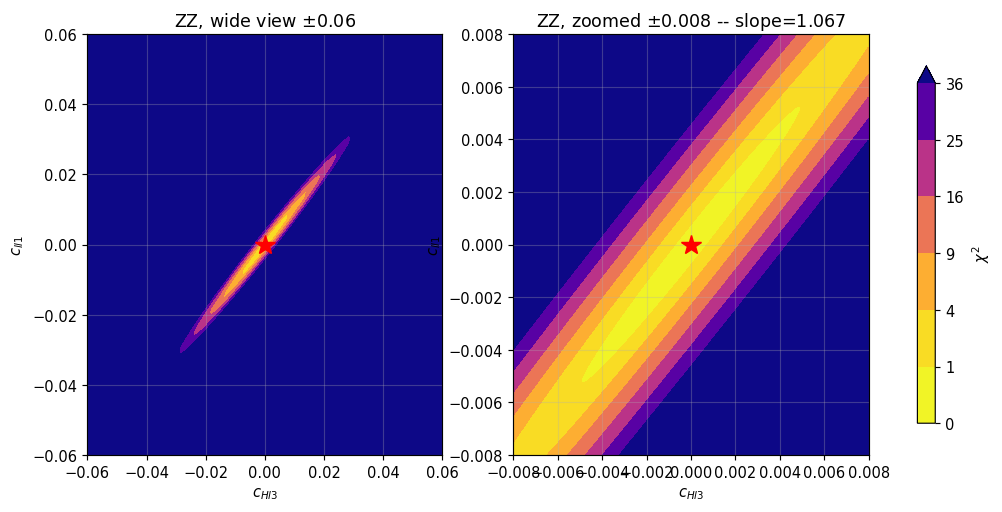

In [29]:
grid_wide = np.linspace(-0.06, 0.06, 81)
grid_zoom = np.linspace(-0.008, 0.008, 121)
Xw, Yw, Zw = fl.chi2_scan_2d(zz["theta"], zz["mu0"], zz["sigma2"], "cHl3", "cll1", grid_wide)
Xz, Yz, Zz2 = fl.chi2_scan_2d(zz["theta"], zz["mu0"], zz["sigma2"], "cHl3", "cll1", grid_zoom)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
levels = [0, 1, 4, 9, 16, 25, 36]

axes[0].contourf(Xw, Yw, Zw, levels=levels, cmap="plasma_r", extend="max")
axes[0].plot(0, 0, "r*", ms=14)
axes[0].set_title("ZZ, wide view $\\pm 0.06$")
axes[0].set_xlabel("$c_{Hl3}$"); axes[0].set_ylabel("$c_{ll1}$")

cs2 = axes[1].contourf(Xz, Yz, Zz2, levels=levels, cmap="plasma_r", extend="max")
axes[1].plot(0, 0, "r*", ms=14)
axes[1].set_title(f"ZZ, zoomed $\\pm 0.008$ -- slope={slope_zz:.3f}")
axes[1].set_xlabel("$c_{Hl3}$"); axes[1].set_ylabel("$c_{ll1}$")
fig.colorbar(cs2, ax=axes, shrink=0.85, label=r"$\chi^2$")
plt.show()

ZZ's valley is wider than WW's (lower statistics, as expected — compare the
zoom scales: $\pm0.008$ here vs. $\pm0.0008$ for WW, a 10x wider zoom just
to resolve it), **and** the marginal correlation is much lower. Let's
quantify precisely, dropping $c_W$ (exactly unconstrained, so it can't be
included in a marginal-covariance matrix inversion for this process alone):

In [30]:
idx_no_cW = [k for k, op in enumerate(OPS) if op != "cW"]
ops_no_cW = [OPS[k] for k in idx_no_cW]
F5_zz = F_zz[np.ix_(idx_no_cW, idx_no_cW)]
cov5_zz = np.linalg.inv(F5_zz)
ii, jj = ops_no_cW.index("cHl3"), ops_no_cW.index("cll1")
corr_zz_cHl3_cll1 = cov5_zz[ii, jj] / np.sqrt(cov5_zz[ii, ii] * cov5_zz[jj, jj])

print(f"ZZ marginal sigma(cHl3) = {np.sqrt(cov5_zz[ii, ii]):.5f}")
print(f"ZZ marginal sigma(cll1) = {np.sqrt(cov5_zz[jj, jj]):.5f}")
print(f"ZZ marginal corr(cHl3, cll1) = {corr_zz_cHl3_cll1:.6f}")
print(f"\ncf. WW marginal corr(cHl3, cll1) = {corr_ww_cHl3_cll1:.6f}")

ZZ marginal sigma(cHl3) = 0.05694
ZZ marginal sigma(cll1) = 0.06127
ZZ marginal corr(cHl3, cll1) = 0.825744

cf. WW marginal corr(cHl3, cll1) = 0.998095


**0.83 vs. 0.998.** ZZ genuinely sees a different combination of
$c_{Hl3}$ and $c_{ll1}$ than WW does — exactly the outcome step 7 predicted
from the vertex structure. On to step 9: combine the two and watch the
flat direction actually close.

## Step 9 — Check the PCA/Fisher matrices: what's different with WW+ZZ combined?

For independent datasets, Fisher information is simply **additive**:
$F_{\rm comb} = F_{WW} + F_{ZZ}$. We'll verify this isn't just a textbook
formula but numerically *exact* here, two independent ways: (a) the direct
matrix sum, and (b) a genuine joint `iminuit` fit on the two samples'
binned predictions concatenated together (i.e. actually re-deriving the
combination from the same $\chi^2$-construction machinery used throughout,
rather than assuming the addition rule).

In [31]:
F_comb = F_ww + F_zz
w_comb, v_comb = fl.eigh_sorted(F_comb)

print("Eigenvalues, WW alone:      ", w_ww)
print("Eigenvalues, WW+ZZ combined:", w_comb)
print(f"\nSmallest-eigenvalue improvement: {w_comb[-1] / w_ww[-1]:.2f}x "
      f"(this used to be the near-flat cHl3/cll1 pair)")

Eigenvalues, WW alone:       [4.78074265e+08 6.60291443e+06 9.14182741e+05 2.95911565e+04
 1.81947639e+03 1.71303801e+03]
Eigenvalues, WW+ZZ combined: [4.83419093e+08 6.67922538e+06 9.62617403e+05 6.29244357e+05
 3.06840922e+04 4.89465602e+03]

Smallest-eigenvalue improvement: 2.86x (this used to be the near-flat cHl3/cll1 pair)


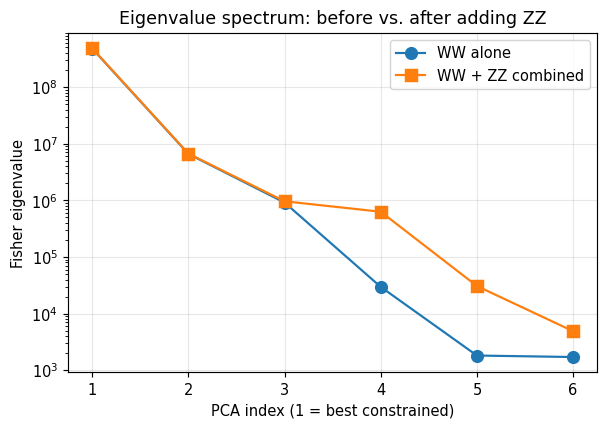

In [32]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
idx = range(1, len(OPS) + 1)
ax.semilogy(idx, w_ww, "o-", label="WW alone", ms=8)
ax.semilogy(idx, w_comb, "s-", label="WW + ZZ combined", ms=8)
ax.set_xticks(idx)
ax.set_xlabel("PCA index (1 = best constrained)")
ax.set_ylabel("Fisher eigenvalue")
ax.set_title("Eigenvalue spectrum: before vs. after adding ZZ")
ax.legend()
plt.show()

In [33]:
# Cross-check: true joint Minuit fit on bin-concatenated theta/mu0/sigma2.
theta_comb = np.concatenate([ww["theta"], zz["theta"]], axis=1)
mu0_comb = np.concatenate([ww["mu0"], zz["mu0"]])
sigma2_comb = np.concatenate([ww["sigma2"], zz["sigma2"]])

m_comb_full = fl.fit_full(theta_comb, mu0_comb, sigma2_comb)
m_comb_full

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 597              │
│ EDM = 5.14e-22 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ cW   │  0.0000   │  0.0015   │  -0.0015   │   0.0015   │   -5    │    5    │       │
│ 1 │ cHWB │  0.0000   │  0.0027   │  -0.0026   │   0.0027   │   -5    │    5    │       │
│ 2 │ cHW  │   0.000   │   0.007   │   -0.007   │   0.007    │   -5    │    5    │       │
│ 3 │ cHj3 │     0     │  0.7e-3   │  -0.7e-3   │   0.7e-3   │   -5    │    5    │       │
│ 4 │ cHl3 │   0.000   │   0.010   │   -0.010   │   0.009    │   -5    │    5    │       │
│ 5 │ cll1 │   0.00    │   0.01    │   -0.01    │    0.01    │   -5    │    5    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          cW           │         cHWB          │          cHW          │         cHj3          │         cHl3          │         cll1          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0015  │  0.0015   │  -0.0026  │  0.0027   │  -0.007   │   0.007   │  -0.7e-3  │  0.7e-3   │  -0.010   │   0.009   │   -0.01   │   0.01    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬───────────────────────────────────────────────────────┐
│      │       cW     cHWB      cHW     cHj3     cHl3     cll1 │
├──────┼───────────────────────────────────────────────────────┤
│   cW │ 2.17e-06  -2.3e-6  -7.2e-6   0.6e-6   8.5e-6   7.8e-6 │
│ cHWB │  -2.3e-6 7.05e-06     9e-6  -0.1e-6   -22e-6   -22e-6 │
│  cHW │  -7.2e-6     9e-6 4.67e-05  -2.8e-6 -0.04e-3 -0.03e-3 │
│ cHj3 │   0.6e-6  -0.1e-6  -2.8e-6 4.73e-07  -0.1e-6  -0.6e-6 │
│ cHl3 │   8.5e-6   -22e-6 -0.04e-3  -0.1e-6  9.1e-05  0.09e-3 │
│ cll1 │   7.8e-6   -22e-6 -0.03e-3  -0.6e-6  0.09e-3 9.21e-05 │
└──────┴───────────────────────────────────────────────────────┘

In [34]:
cov_comb_minuit = np.array(m_comb_full.covariance)
cov_comb_fisher = np.linalg.inv(F_comb)
print("max |joint-Minuit-fit covariance - Fisher-matrix-sum-inverse covariance| =",
      np.max(np.abs(cov_comb_minuit - cov_comb_fisher)))
print("(should be ~floating-point-level -- two independent derivations of the same object)")

max |joint-Minuit-fit covariance - Fisher-matrix-sum-inverse covariance| = 8.29197947572628e-08
(should be ~floating-point-level -- two independent derivations of the same object)


Both routes to "combine WW and ZZ" — summing Fisher matrices, and actually
re-fitting a joint likelihood — agree to floating-point precision. Now the
headline numbers:

In [35]:
corr_comb = cov_comb_fisher[i_hl3, i_ll1] / np.sqrt(cov_comb_fisher[i_hl3, i_hl3] * cov_comb_fisher[i_ll1, i_ll1])
sig_cHl3_comb = np.sqrt(cov_comb_fisher[i_hl3, i_hl3])
sig_cll1_comb = np.sqrt(cov_comb_fisher[i_ll1, i_ll1])

summary = pd.DataFrame({
    "sigma, WW alone": np.sqrt(np.diag(cov_ww_fisher)),
    "sigma, WW+ZZ": np.sqrt(np.diag(cov_comb_fisher)),
}, index=OPS)
summary["improvement"] = summary["sigma, WW alone"] / summary["sigma, WW+ZZ"]
display(summary.style.format("{:.4f}"))

print(f"\ncorr(cHl3, cll1): WW alone = {corr_ww_cHl3_cll1:.6f}  ->  WW+ZZ combined = {corr_comb:.6f}")
print(f"sigma(cHl3):      WW alone = {sig_cHl3_ww:.5f}  ->  WW+ZZ combined = {sig_cHl3_comb:.5f}"
      f"  ({sig_cHl3_ww/sig_cHl3_comb:.2f}x tighter)")
print(f"sigma(cll1):      WW alone = {sig_cll1_ww:.5f}  ->  WW+ZZ combined = {sig_cll1_comb:.5f}"
      f"  ({sig_cll1_ww/sig_cll1_comb:.2f}x tighter)")

,"sigma, WW alone","sigma, WW+ZZ",improvement
cW,0.0020,0.0015,1.3581
cHWB,0.0240,0.0027,9.0478
cHW,0.0097,0.0068,1.4176
cHj3,0.0009,0.0007,1.2638
cHl3,0.0158,0.0095,1.6521
cll1,0.0156,0.0096,1.6256



corr(cHl3, cll1): WW alone = 0.998095  ->  WW+ZZ combined = 0.996536
sigma(cHl3):      WW alone = 0.01577  ->  WW+ZZ combined = 0.00954  (1.65x tighter)
sigma(cll1):      WW alone = 0.01561  ->  WW+ZZ combined = 0.00960  (1.63x tighter)


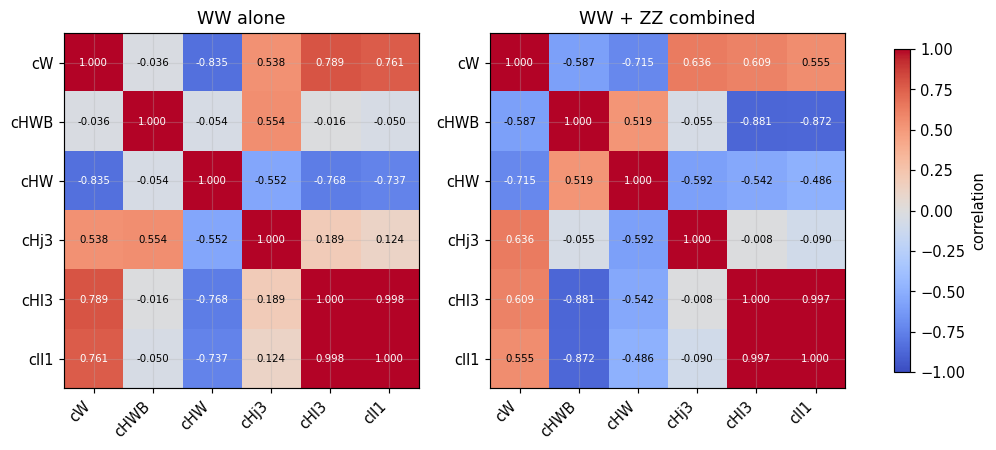

In [36]:
corr_comb_full = fl.correlation_matrix(cov_comb_fisher)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, C, title in zip(axes, [corr_ww_minuit, corr_comb_full], ["WW alone", "WW + ZZ combined"]):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(OPS))); ax.set_xticklabels(OPS, rotation=45, ha="right")
    ax.set_yticks(range(len(OPS))); ax.set_yticklabels(OPS)
    ax.set_title(title)
    for a in range(len(OPS)):
        for b in range(len(OPS)):
            ax.text(b, a, f"{C[a, b]:.3f}", ha="center", va="center", fontsize=7,
                     color="white" if abs(C[a, b]) > 0.6 else "black")
fig.colorbar(im, ax=axes, shrink=0.8, label="correlation")
plt.show()

Notice $c_{Hl3}$–$c_{ll1}$ drops from $\approx0.998$ to $\approx0.997$ —
only a small *absolute* change, but don't be fooled by that: correlation
saturates near $\pm1$, so the *uncertainty* it corresponds to shrinks by
1.65x (table above) — a highly nonlinear relationship between "correlation
coefficient" and "how open the flat direction is". Also notice the
$c_{HWB}$ row/column changes a lot more dramatically (e.g. its uncertainty
tightens by roughly 9x) — ZZ is directly sensitive to $c_{HWB}$ in a way
that introduces genuinely new correlations (e.g. $c_{HWB}$–$c_{Hl3}$) that
simply aren't present in WW alone. Adding a process doesn't just shrink
errors along the one direction you were targeting; it reshapes the whole
correlation structure, for better or worse — always look at the full
matrix, not just the one number you were hoping to improve.

Finally, the visual version of "closing the flat direction" — the two
valleys, overlaid:

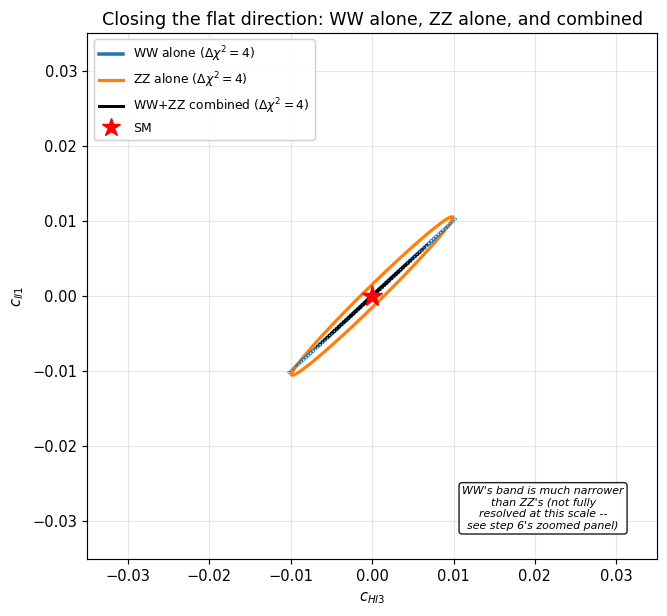

In [37]:
grid = np.linspace(-0.035, 0.035, 241)
_, _, Z_ww_ov = fl.chi2_scan_2d(ww["theta"], ww["mu0"], ww["sigma2"], "cHl3", "cll1", grid)
X_ov, Y_ov, Z_zz_ov = fl.chi2_scan_2d(zz["theta"], zz["mu0"], zz["sigma2"], "cHl3", "cll1", grid)
Z_comb_ov = Z_ww_ov + Z_zz_ov  # chi2 is additive for independent datasets, same rule as the Fisher matrices

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.contourf(X_ov, Y_ov, Z_comb_ov, levels=[0, 4], colors=["#cfe8cf"], zorder=1)
ax.contour(X_ov, Y_ov, Z_zz_ov, levels=[4], colors="C1", linewidths=2.2, zorder=2)
ax.contour(X_ov, Y_ov, Z_ww_ov, levels=[4], colors="C0", linewidths=2.4, zorder=3)
ax.contour(X_ov, Y_ov, Z_comb_ov, levels=[4], colors="k", linewidths=2.0, zorder=4)
ax.plot(0, 0, "r*", ms=15, zorder=5)

handles = [
    Line2D([0], [0], color="C0", lw=2.4, label=r"WW alone ($\Delta\chi^2=4$)"),
    Line2D([0], [0], color="C1", lw=2.2, label=r"ZZ alone ($\Delta\chi^2=4$)"),
    Line2D([0], [0], color="k", lw=2.0, label=r"WW+ZZ combined ($\Delta\chi^2=4$)"),
    Line2D([0], [0], marker="*", color="r", lw=0, markersize=13, label="SM"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8.5, framealpha=0.9)
ax.set_xlabel("$c_{Hl3}$"); ax.set_ylabel("$c_{ll1}$")
ax.set_title("Closing the flat direction: WW alone, ZZ alone, and combined")
ax.text(0.021, -0.031, "WW's band is much narrower\nthan ZZ's (not fully\nresolved at this scale --\nsee step 6's zoomed panel)",
        fontsize=7.5, ha="center", style="italic",
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))
plt.show()

WW alone (blue) constrains the *perpendicular* direction exquisitely but
is essentially unconstrained along its own long axis within this window.
ZZ alone (orange) is a fatter ellipse tilted at a visibly different angle.
Combined (black/green): the crossing of two differently-tilted, precise-in-
one-direction constraints pins down a genuinely small region — **this is
what "closing a flat direction" looks like**, not a formula, an actual
picture of two valleys that don't line up.

## Step 10 — Competition: who can pin down $c_{ll1}$ the tightest?

Time to turn the machinery from steps 3–9 into a game. Forget the full 6D
fit for a moment: **restrict to just $c_{Hl3}$ and $c_{ll1}$**, fixing the
other four operators to exactly 0. Thanks to the surface fitted in step 2
being an *exact* quadratic in all 6 coefficients, "fixing
$c_W=c_{HWB}=c_{HW}=c_{Hj3}=0$" in that already-fitted surface is
mathematically identical to never having included them in the first place
— every cross term touching them simply evaluates to 0. No new generation,
no new surface: just `Minuit.fixed`, exposed here as a `fixed=` option on
`fit_full()` (see `fitlib.py`).

**The rules.** Pick a dataset — WW alone, ZZ alone, or WW+ZZ combined (feel
free to add CC-DY too; step 7 already told you what to expect from that
one). Get the smallest possible 1-$\sigma$ uncertainty on $c_{ll1}$,
**properly profiling over $c_{Hl3}$**: at every trial value of $c_{ll1}$,
$c_{Hl3}$ is free to move to whatever value best fits the data — exactly
what MINOS does internally, and exactly what you should always do with a
correlated parameter you're not directly interested in.

**The catch.** For every dataset you try, also do the tempting, lazy
version: fix $c_{Hl3}=0$ outright instead of profiling it — "I only care
about $c_{ll1}$ anyway, right?" That fit will *always* come out tighter.
Whenever $c_{Hl3}$ and $c_{ll1}$ are genuinely correlated, it is also
**wrong**: not a measurement of $c_{ll1}$, but a measurement of $c_{ll1}$
*conditional on an assumption about $c_{Hl3}$ the data gave you no
license to make*. The gap between the two numbers is a direct,
quantitative readout of how much that unjustified assumption was doing
the work — and, as you're about to see, it shrinks exactly when (and
because) the flat direction closes.

In [38]:
OTHER_OPS = [op for op in OPS if op not in ("cHl3", "cll1")]
i_cll1 = OPS.index("cll1")


def sub2_sigma_cll1(F):
    # Linearized (Fisher) sigma(cll1) with cHl3 PROFILED and every other
    # operator fixed at 0 -- the same 2x2 conditional sub-block already
    # used in steps 6/8, inverted.
    F2 = F[np.ix_([i_hl3, i_ll1], [i_hl3, i_ll1])]
    cov2 = np.linalg.inv(F2)
    return float(np.sqrt(cov2[1, 1]))


def diag_sigma_cll1(F):
    # Linearized (Fisher) sigma(cll1) for the NAIVE fit -- cHl3 fixed too,
    # so there's nothing left to marginalize/correlate against: a single
    # free parameter's sigma is just 1/sqrt(F_ii), no inversion needed.
    return float(1.0 / np.sqrt(F[i_ll1, i_ll1]))


# These are only used to size the nonlinear scan grids below -- notice the
# naive and profiled scales below are wildly different (up to ~300x for
# WW!) for exactly the reason step 3/6 already flagged: cHl3 and cll1 are
# almost totally degenerate for WW, so "let cHl3 float" vs. "pin it to 0"
# are barely-related fits with barely-related widths. That gap is why the
# two curves below get their OWN grids instead of sharing one -- a single
# grid fine enough for the naive curve would need >10000 points to also
# resolve the (much wider) profiled curve out to the same relative
# precision, and a grid sized for the profiled curve is far too coarse to
# resolve the naive one at all (ask us how we found that out).
sig_naive_ww, sig_prof_ww = diag_sigma_cll1(F_ww), sub2_sigma_cll1(F_ww)
sig_naive_zz, sig_prof_zz = diag_sigma_cll1(F_zz), sub2_sigma_cll1(F_zz)
sig_naive_comb, sig_prof_comb = diag_sigma_cll1(F_comb), sub2_sigma_cll1(F_comb)

print("Every operator except cHl3 and cll1 is fixed to exactly 0 for this whole section:")
print(" ", OTHER_OPS)
print()
print("Linearized (Fisher) sigma(cll1) previews -- naive (cHl3 fixed=0) vs.")
print("profiled (cHl3 free) -- used only to size the nonlinear scan grids below:")
print(f"  WW alone:       naive~{sig_naive_ww:.6f}   profiled~{sig_prof_ww:.5f}   (ratio {sig_prof_ww/sig_naive_ww:.1f}x)")
print(f"  ZZ alone:       naive~{sig_naive_zz:.6f}   profiled~{sig_prof_zz:.5f}   (ratio {sig_prof_zz/sig_naive_zz:.1f}x)")
print(f"  WW+ZZ combined: naive~{sig_naive_comb:.6f}   profiled~{sig_prof_comb:.5f}   (ratio {sig_prof_comb/sig_naive_comb:.1f}x)")

Every operator except cHl3 and cll1 is fixed to exactly 0 for this whole section:
  ['cW', 'cHWB', 'cHW', 'cHj3']

Linearized (Fisher) sigma(cll1) previews -- naive (cHl3 fixed=0) vs.
profiled (cHl3 free) -- used only to size the nonlinear scan grids below:
  WW alone:       naive~0.000081   profiled~0.00582   (ratio 71.5x)
  ZZ alone:       naive~0.000771   profiled~0.00530   (ratio 6.9x)
  WW+ZZ combined: naive~0.000081   profiled~0.00370   (ratio 45.7x)


In [39]:
def run_competition_entry(theta, mu0, sigma2, label, naive_scale, profiled_scale, color):
    # One competition entry for a given dataset: build the naive ("fix
    # cHl3=0") and profiled ("minimize over cHl3") 1D chi2(cll1) curves --
    # each on ITS OWN appropriately-scaled grid (see why in the markdown/
    # comments above) -- read sigma(cll1) off each via the chi2_min+1
    # crossing (sigma_from_curve), and cross-check against a genuine
    # restricted Minuit fit (cHl3 fixed vs. free; everything else always
    # fixed=0 via fit_full's new `fixed=` kwarg).
    grid_naive = np.linspace(-6 * naive_scale, 6 * naive_scale, 161)
    grid_prof = np.linspace(-6 * profiled_scale, 6 * profiled_scale, 161)

    chi2_naive = fl.chi2_curve_1d(theta, mu0, sigma2, "cll1", grid_naive, fixed={"cHl3": 0.0})
    chi2_prof, _ = fl.profile_1d(theta, mu0, sigma2, "cll1", grid_prof, profile_ops=["cHl3"])

    sig_naive = fl.sigma_from_curve(grid_naive, chi2_naive)
    sig_prof = fl.sigma_from_curve(grid_prof, chi2_prof)

    m_naive = fl.fit_full(theta, mu0, sigma2, fixed=OTHER_OPS + ["cHl3"])
    m_prof = fl.fit_full(theta, mu0, sigma2, fixed=OTHER_OPS)
    if not (m_naive.valid and m_prof.valid):
        print(f"  [warn] Minuit fit not valid for {label} "
              f"(naive valid={m_naive.valid}, profiled valid={m_prof.valid})")
    sig_naive_minuit = float(np.sqrt(np.array(m_naive.covariance)[i_cll1, i_cll1]))
    sig_prof_minuit = float(np.sqrt(np.array(m_prof.covariance)[i_cll1, i_cll1]))

    print(f"[{label}]")
    print(f"  naive    (cHl3 fixed=0): sigma(cll1) = {sig_naive:.6f}  (curve)   "
          f"{sig_naive_minuit:.6f}  (Minuit HESSE)")
    print(f"  profiled (cHl3 free)   : sigma(cll1) = {sig_prof:.6f}  (curve)   "
          f"{sig_prof_minuit:.6f}  (Minuit HESSE)")
    print(f"  penalty for profiling honestly instead of cheating = {sig_prof / sig_naive:.2f}x wider")
    print()

    return dict(label=label, grid_naive=grid_naive, grid_prof=grid_prof,
                chi2_naive=chi2_naive, chi2_prof=chi2_prof,
                sig_naive=sig_naive, sig_prof=sig_prof, color=color)


entry_ww = run_competition_entry(ww["theta"], ww["mu0"], ww["sigma2"], "WW alone",
                                  sig_naive_ww, sig_prof_ww, "C0")
entry_zz = run_competition_entry(zz["theta"], zz["mu0"], zz["sigma2"], "ZZ alone",
                                  sig_naive_zz, sig_prof_zz, "C1")
entry_comb = run_competition_entry(theta_comb, mu0_comb, sigma2_comb, "WW + ZZ combined",
                                    sig_naive_comb, sig_prof_comb, "k")

[WW alone]
  naive    (cHl3 fixed=0): sigma(cll1) = 0.000081  (curve)   0.000081  (Minuit HESSE)
  profiled (cHl3 free)   : sigma(cll1) = 0.005814  (curve)   0.005765  (Minuit HESSE)
  penalty for profiling honestly instead of cheating = 71.49x wider

[ZZ alone]
  naive    (cHl3 fixed=0): sigma(cll1) = 0.000771  (curve)   0.000771  (Minuit HESSE)
  profiled (cHl3 free)   : sigma(cll1) = 0.005299  (curve)   0.005303  (Minuit HESSE)
  penalty for profiling honestly instead of cheating = 6.88x wider

[WW + ZZ combined]
  naive    (cHl3 fixed=0): sigma(cll1) = 0.000081  (curve)   0.000081  (Minuit HESSE)
  profiled (cHl3 free)   : sigma(cll1) = 0.003700  (curve)   0.003702  (Minuit HESSE)
  penalty for profiling honestly instead of cheating = 45.74x wider



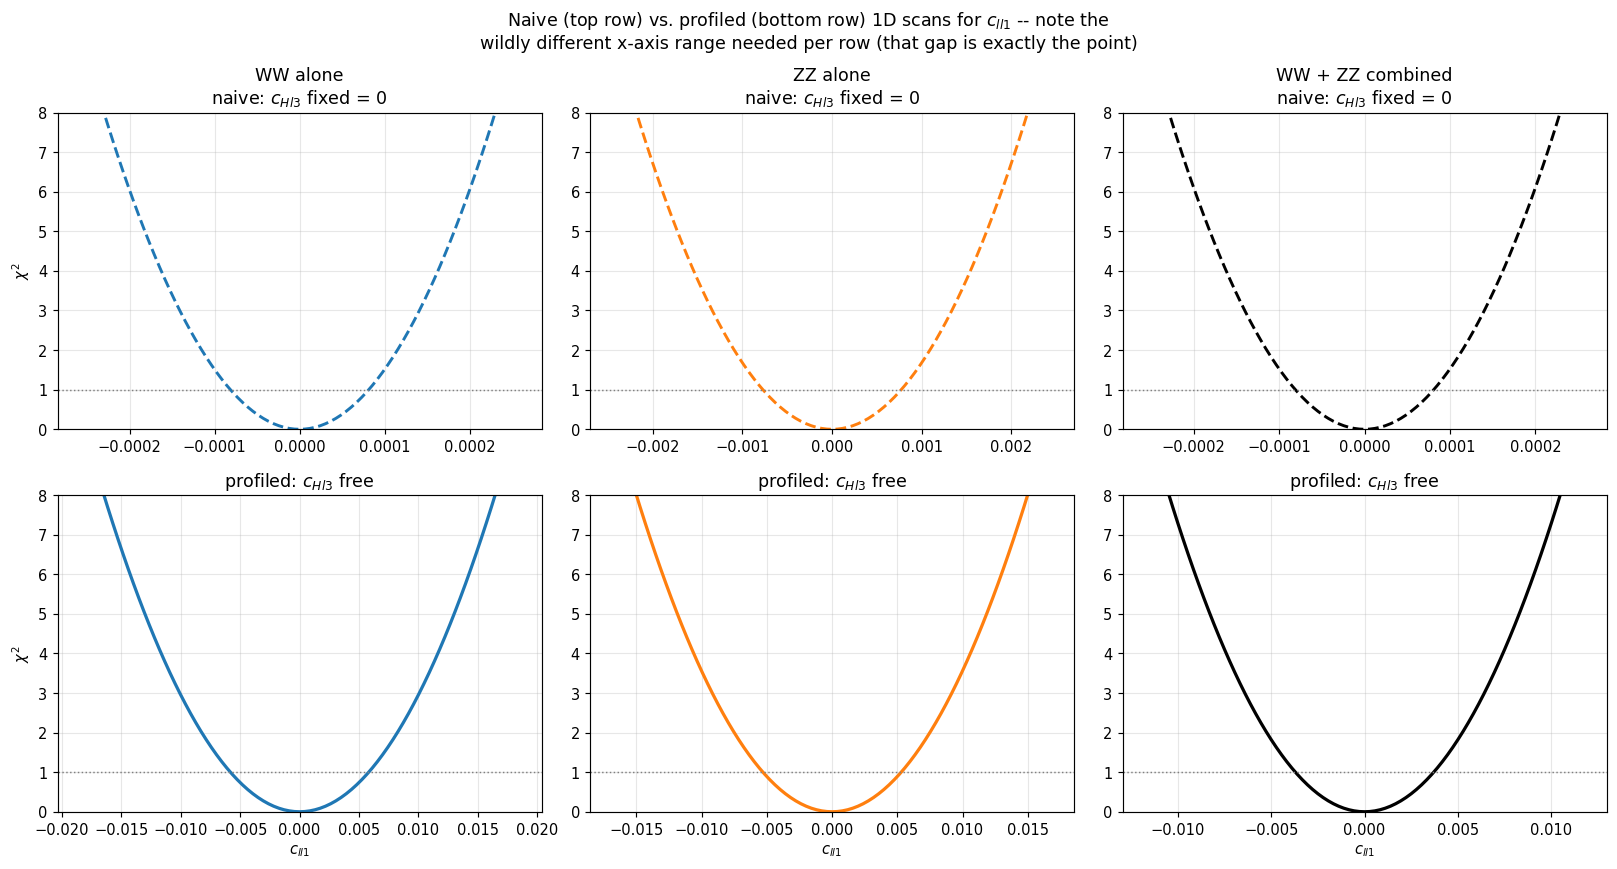

In [40]:
# Two rows (naive on top, profiled on bottom) rather than one shared-axis
# overlay: the naive and profiled curves live at such different physical
# scales (see the ratio column printed above) that no single linear x-axis
# can show both clearly at once -- same lesson as step 6's wide/zoom pair,
# applied here to "naive vs. profiled" instead of "wide vs. zoomed".
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))
for col, entry in enumerate([entry_ww, entry_zz, entry_comb]):
    ax_top, ax_bot = axes[0, col], axes[1, col]

    ax_top.plot(entry["grid_naive"], entry["chi2_naive"], color=entry["color"], ls="--", lw=2)
    ax_top.axhline(1.0, color="gray", lw=1, ls=":")
    ax_top.set_title(f"{entry['label']}\nnaive: $c_{{Hl3}}$ fixed = 0")
    ax_top.set_xlim(-3.5 * entry["sig_naive"], 3.5 * entry["sig_naive"])
    ax_top.set_ylim(0, 8)

    ax_bot.plot(entry["grid_prof"], entry["chi2_prof"], color=entry["color"], ls="-", lw=2.2)
    ax_bot.axhline(1.0, color="gray", lw=1, ls=":")
    ax_bot.set_title("profiled: $c_{Hl3}$ free")
    ax_bot.set_xlabel("$c_{ll1}$")
    ax_bot.set_xlim(-3.5 * entry["sig_prof"], 3.5 * entry["sig_prof"])
    ax_bot.set_ylim(0, 8)

axes[0, 0].set_ylabel(r"$\chi^2$")
axes[1, 0].set_ylabel(r"$\chi^2$")
fig.suptitle("Naive (top row) vs. profiled (bottom row) 1D scans for $c_{ll1}$ -- note the\n"
             "wildly different x-axis range needed per row (that gap is exactly the point)")
plt.tight_layout()
plt.show()

In [41]:
leaderboard = pd.DataFrame([
    dict(dataset=e["label"], sigma_naive=e["sig_naive"], sigma_profiled=e["sig_prof"],
         penalty=e["sig_prof"] / e["sig_naive"])
    for e in [entry_ww, entry_zz, entry_comb]
]).sort_values("sigma_profiled").reset_index(drop=True)

display(leaderboard.style.format({"sigma_naive": "{:.5f}", "sigma_profiled": "{:.5f}", "penalty": "{:.2f}x"})
        .background_gradient(subset=["sigma_profiled"], cmap="viridis_r"))
print(f"Winner (smallest HONEST, profiled sigma(cll1)): {leaderboard.iloc[0]['dataset']}")

,dataset,sigma_naive,sigma_profiled,penalty
0,WW + ZZ combined,0.00008,0.00370,45.74x
1,ZZ alone,0.00077,0.00530,6.88x
2,WW alone,0.00008,0.00581,71.49x


Winner (smallest HONEST, profiled sigma(cll1)): WW + ZZ combined


**Reading the leaderboard:**

- **The naive number is always smaller than the profiled one.** That's not
  a coincidence, it's a general fact about profile likelihoods: pinning a
  correlated parameter to a specific value can only remove freedom the fit
  could otherwise use to describe the data, so the profiled (honestly
  marginalized) uncertainty can never be smaller than the naive (fixed)
  one. If you ever see the opposite in a real analysis, something is
  broken.
- **WW alone has by far the worst penalty** — exactly because $c_{Hl3}$
  and $c_{ll1}$ are almost perfectly degenerate there (steps 3/6:
  $\mathrm{corr}\approx0.998$). Fixing $c_{Hl3}=0$ silently throws away
  the one thing that was making the fit hard, and the "constraint" you get
  back is really a constraint on $c_{ll1}$ *assuming $c_{Hl3}$ happens to
  be exactly 0* — an assumption WW data alone gives you no way to justify.
- **WW+ZZ combined wins the honest metric**: its profiled
  $\sigma(c_{ll1})$ is the tightest of the three (ZZ's different vertex
  structure, step 7, is doing real work here). But look at its *penalty*
  column before celebrating too hard — it is still large, nowhere near the
  smallest of the three.
- **ZZ alone has the smallest penalty, by a wide margin** — and for a
  different reason than "closing the flat direction". ZZ's own
  $c_{Hl3}$-$c_{ll1}$ correlation is much weaker to begin with
  ($\mathrm{corr}\approx0.83$, step 8) than WW's ($\approx0.998$), so
  fixing $c_{Hl3}=0$ costs ZZ comparatively little: naive and profiled
  were never that far apart for ZZ in the first place. That is *not* the
  same as "ZZ pins down $c_{ll1}$ best" — ZZ's absolute profiled
  $\sigma(c_{ll1})$ is still looser than the combined fit's; it's just a
  smaller step down from its own (already decent) naive number.
- **So why doesn't combining WW+ZZ also collapse the penalty, given that
  step 9 showed it closes the flat direction?** Because "closes" is
  relative: the combined correlation only drops from $\approx0.998$ (WW
  alone) to $\approx0.997$ (combined, step 9) — a tiny move on the
  correlation-coefficient scale. But exactly as step 9's own aspect-ratio
  numbers warned, correlation near $\pm1$ is a highly nonlinear,
  saturating readout of how open a direction really is: a whisker of
  residual correlation can still hide most of one parameter behind
  another. **The penalty ratio and the absolute profiled uncertainty are
  answers to two different questions** — how much an unjustified
  assumption is still buying you, versus how much total information the
  dataset carries — and WW+ZZ combined wins the second without winning the
  first. That's real progress, just not the kind the naive number would
  have led you to expect.

The lesson generalizes well beyond this one pair of operators: any time
you see a single-operator SMEFT limit quoted in a paper or a plot, ask
whether it's profiled or naive. A naive limit is really a statement about
a 1-parameter model in which every other Wilson coefficient is *assumed*
to be exactly zero — precisely the assumption a global fit exists to
avoid making.

## Closing remarks

**What we did, in one paragraph:** picked a genuine multiboson process
(WW→eμ+MET), reweighted it to a 6D dimension-6 SMEFT basis with an exact
quadratic response surface, built an Asimov $\chi^2$ and fit it with
`iminuit` from the SM starting point, found (via the Fisher matrix's
eigenvalue spectrum, and confirmed via a genuine fit failure) that 2 of the
6 directions are so weakly constrained that a simultaneous 6-parameter fit
isn't trustworthy, traced the worst offender ($c_{Hl3}$–$c_{ll1}$) to a
universal electroweak-input-scheme shift ($\delta G_F$) using the actual
UFO model source, used that same source to predict (and then verified,
from real generated events, not just asserted) that a second, neutral-
current multiboson process would see a different combination of the same
two operators, and combined the two Fisher matrices — cross-checked against
a genuine joint fit — to watch the flat direction actually close.

**Bonus round, if you have time left:** two more dimension-6 operators,
$c_{HB}$ and $c_{HDD}$, were deliberately left out of the 6-operator basis
here to keep a 4h session tractable. Both are already supported by
`reweight_points.py`'s `SMEFT_INDEX` convention (just not included in
`OPERATORS`) — try adding them to the basis, regenerating the reweight
card, and re-running this notebook unchanged (every function here is
written generically in terms of `reweight_points.OPERATORS`, so nothing
downstream needs to change).

**Other things worth poking at:**
- Change `LUMI_FB` and re-run from step 3 onward — watch which directions
  count as "flat" depend on assumed statistics, exactly as they should.
- The muon channel of CC-DY was skipped (see `create_ccdy.sh`) because
  $c_{Hl3}/c_{ll1}/c_{Hj3}$ are lepton-flavour-universal in this UFO's
  flavour scheme — verify that claim empirically instead of taking the
  comment's word for it.
- Try `fit_reduced` with `k_keep=5` on ZZ (i.e. keep everything except the
  one exactly-flat $c_W$ direction) and see whether it converges.